# 🌲 Gradient Boosting — XGBoost, LightGBM & CatBoost for Tabular Data

> **What you'll learn:** how gradient boosting turns many small, weak decision trees into one of the strongest models for spreadsheet-style data. You will build it from scratch, derive XGBoost's split formula by hand, tune and early-stop XGBoost, LightGBM, CatBoost and scikit-learn's HistGradientBoosting on real census data, and explain predictions with SHAP.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (loss, gradient descent, overfitting, metrics) · [Scikit-Learn](02_Scikit_Learn.ipynb) (fit/predict, splits, cross-validation, decision trees) · [Decision Trees](08_Decision_Trees.ipynb) · [Random Forest & Bagging](09_Random_Forest_and_Bagging.ipynb) |
| **Tested with** | Python 3.12 · xgboost 3.4 · lightgbm 4.7 · catboost 1.2 · scikit-learn 1.9 · shap 0.52 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ Very high — "bagging vs boosting", "how does gradient boosting work?", XGBoost's gain formula, leaf-wise vs level-wise, CatBoost and target leakage, early stopping, SHAP vs feature importance |

## 🤔 What Is Gradient Boosting?

Imagine a team of weather forecasters working **one after another**:

1. The first forecaster makes a rough guess for every city.
2. The second one doesn't start from zero. They look only at **where the first guess was wrong** and learn a small correction.
3. The third corrects what is *still* wrong after the first two, and so on.

Each forecaster is not very clever on their own (a **weak learner**). But hundreds of small corrections, each fixing the remaining mistakes, add up to an excellent forecast.

**Gradient boosting** does exactly this with **decision trees**:

```
prediction = starting guess + η·tree₁(x) + η·tree₂(x) + η·tree₃(x) + ...
                                ↑ each tree is trained on the errors left by all trees before it
```

- **Boosting** = building models *sequentially*, each one focusing on the previous mistakes.
- **Gradient** = the "mistakes" are measured with the *gradient of a loss function* (for squared error this is just the residual `y − prediction`).
- **η (eta), the learning rate** = how big a step each tree is allowed to take.

**XGBoost**, **LightGBM** and **CatBoost** are three famous, highly optimized libraries that implement this idea, each with its own tricks.

## 🎯 Why It Matters

- **It is the default model for tabular data in industry.** Credit scoring, fraud detection, click-through prediction, churn, demand forecasting, insurance pricing and ranking systems very often run on gradient-boosted trees.
- **It still beats deep learning on typical tabular datasets.** Large benchmarks (e.g. Grinsztajn et al., 2022, linked in Resources) found tree ensembles ahead of neural networks on medium-sized tables.
- **It is fast and practical.** Handles mixed numeric/categorical columns, missing values and unscaled features with little preprocessing, and trains in seconds on a laptop.
- **In interviews** it is one of the most common ML topics: *"bagging vs boosting"*, *"walk me through how gradient boosting works"*, *"why does XGBoost use the second derivative?"*, *"LightGBM vs XGBoost vs CatBoost?"*, *"how would you handle imbalance / missing values / leakage?"*, *"why not trust feature importance?"*. This notebook practises all of them.

## ✅ By the End You Can

- [ ] Explain bagging vs boosting and how gradient boosting fits trees to negative gradients (residuals)
- [ ] Derive XGBoost's optimal leaf weight $-G/(H+\lambda)$ and split gain, and verify them against a trained booster
- [ ] Tune the key hyperparameters, spot overfitting, and use early stopping on a **validation** set
- [ ] Use XGBoost, LightGBM, CatBoost and HistGradientBoosting with native categoricals, missing values and class imbalance
- [ ] Explain models with SHAP and say why built-in importances can mislead
- [ ] Run a fair, leakage-free comparison and defend the winner in an interview

## 📋 Table of Contents

1. [Decision Trees: A Quick Recap](#1.-Decision-Trees:-A-Quick-Recap-🟢)
2. [Ensembles: Bagging vs Boosting](#2.-Ensembles:-Bagging-vs-Boosting-🟢)
3. [Gradient Boosting Intuition: Fitting Residuals](#3.-Gradient-Boosting-Intuition:-Fitting-Residuals-🟢)
4. [The XGBoost Objective: Gradients, Hessians, and Gain](#4.-The-XGBoost-Objective:-Gradients,-Hessians,-and-Gain-🟡)
5. [Key Hyperparameters and Overfitting](#5.-Key-Hyperparameters-and-Overfitting-🟡)
6. [Early Stopping on a Validation Set](#6.-Early-Stopping-on-a-Validation-Set-🟡)
7. [XGBoost in Practice](#7.-XGBoost-in-Practice-🟡)
8. [LightGBM in Practice](#8.-LightGBM-in-Practice-🟡)
9. [CatBoost in Practice](#9.-CatBoost-in-Practice-🟡)
10. [HistGradientBoosting: The Built-In Baseline](#10.-HistGradientBoosting:-The-Built-In-Baseline-🟢)
11. [Explaining Models: Importances vs SHAP](#11.-Explaining-Models:-Importances-vs-SHAP-🟡)
12. [A Fair Head-to-Head Comparison](#12.-A-Fair-Head-to-Head-Comparison-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Adult-Income-Prediction-With-Four-Boosters) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel. (On macOS, XGBoost and LightGBM also need the OpenMP runtime: `brew install libomp`.)

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

Two datasets are downloaded once and cached by scikit-learn (about 3 MB in total): **California housing** (regression) and **Adult census income** (classification).

In [1]:
# %pip install -q "xgboost>=3.0" "lightgbm>=4.6" "catboost>=1.2" "scikit-learn>=1.6" "shap>=0.47" "pandas>=2.2" matplotlib

import json
import sys
import time
import warnings
from pathlib import Path

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.datasets import fetch_california_housing, fetch_openml, load_breast_cancer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text

with warnings.catch_warnings():
    # shap 0.52 triggers a harmless matplotlib colormap PendingDeprecationWarning at import time
    warnings.simplefilter("ignore", PendingDeprecationWarning)
    import shap

print(f"Python {sys.version.split()[0]} | xgboost {xgb.__version__} | lightgbm {lgb.__version__} | "
      f"catboost {cb.__version__} | scikit-learn {sklearn.__version__} | shap {shap.__version__} | pandas {pd.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, dict):
        ok = isinstance(got, dict) and set(got) == set(expected) and all(
            np.allclose(got[k], expected[k], rtol=rtol, atol=atol) for k in expected)
    elif isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | xgboost 3.4.1 | lightgbm 4.7.0 | catboost 1.2.10 | scikit-learn 1.9.1 | shap 0.52.0 | pandas 3.0.5


## 1. Decision Trees: A Quick Recap 🟢

Every booster in this notebook is a sum of **decision trees**, so let's refresh what one tree does.

A **regression tree** asks yes/no questions about features (`MedInc <= 5.0?`) and ends in a **leaf** that holds a single number: the average target of the training rows that landed there.

```
                MedInc <= 5.03?
               /               \
         yes  /                 \  no
    MedInc <= 3.07?        MedInc <= 6.82?
      /      \               /       \
   leaf     leaf          leaf      leaf        ← each leaf predicts one constant
```

- **Depth** = how many questions in a row. A depth-`d` tree has at most $2^d$ leaves.
- **Shallow trees** are simple and *underfit* (high bias).
- **Deep trees** memorize the training set and *overfit* (high variance).

We use the **California housing** dataset: 20,640 districts, 8 numeric features, target = median house value in units of \$100,000.

In [2]:
housing = fetch_california_housing(as_frame=True)
X_house, y_house = housing.data, housing.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_house, y_house, test_size=0.2, random_state=SEED)
print("train:", Xh_train.shape, "| test:", Xh_test.shape)
print(X_house.head(3))

for depth in [1, 3, 6, 12, None]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=SEED).fit(Xh_train, yh_train)
    print(f"max_depth={str(depth):>4} | leaves={tree.get_n_leaves():>6} | "
          f"train R² {r2_score(yh_train, tree.predict(Xh_train)):.3f} | test R² {r2_score(yh_test, tree.predict(Xh_test)):.3f}")

train: (16512, 8) | test: (4128, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0    6.9841     1.0238       322.0    2.5556     37.88   
1  8.3014      21.0    6.2381     0.9719      2401.0    2.1098     37.86   
2  7.2574      52.0    8.2881     1.0734       496.0    2.8023     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
max_depth=   1 | leaves=     2 | train R² 0.317 | test R² 0.280
max_depth=   3 | leaves=     8 | train R² 0.538 | test R² 0.510
max_depth=   6 | leaves=    64 | train R² 0.678 | test R² 0.621
max_depth=  12 | leaves=  2051 | train R² 0.899 | test R² 0.670
max_depth=None | leaves= 15870 | train R² 1.000 | test R² 0.616


In [3]:
# A depth-2 tree is literally 3 if/else questions and 4 constants
small_tree = DecisionTreeRegressor(max_depth=2, random_state=SEED).fit(Xh_train, yh_train)
print(export_text(small_tree, feature_names=list(X_house.columns), decimals=2))

|--- MedInc <= 5.09
|   |--- MedInc <= 3.07
|   |   |--- value: [1.36]
|   |--- MedInc >  3.07
|   |   |--- value: [2.09]
|--- MedInc >  5.09
|   |--- MedInc <= 6.89
|   |   |--- value: [2.95]
|   |--- MedInc >  6.89
|   |   |--- value: [4.26]



Notice the pattern: training R² keeps rising with depth, but test R² peaks and then **falls** — the unlimited tree reaches R² = 1.0 on training data by memorizing it. A single tree is either too simple or too wiggly. **Ensembles** fix this.

### ✍️ Your Turn

Fit a `DecisionTreeRegressor` with `max_depth=3` on `Xh_train, yh_train` and store its **number of leaves** in `n_leaves`.

In [4]:
n_leaves = None  # TODO: your code here
check("n_leaves", n_leaves, 8, hint="Use .get_n_leaves() on the fitted tree. A depth-3 binary tree has at most 2**3 leaves.")

⏳ n_leaves: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_leaves = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(Xh_train, yh_train).get_n_leaves()
check("n_leaves", n_leaves, 8)
```

With 16,000+ rows every split is possible, so the tree is "full": $2^3 = 8$ leaves.
</details>

> 💡 **Interview angle:** "Why are trees popular base learners for boosting?" — they handle mixed feature types, need no scaling, capture interactions and non-linearities automatically, and a *shallow* tree is a fast, low-variance weak learner.

## 2. Ensembles: Bagging vs Boosting 🟢

An **ensemble** combines many models. There are two big families:

| | **Bagging** (e.g. Random Forest) | **Boosting** (e.g. Gradient Boosting) |
|---|---|---|
| How trees are built | **In parallel**, independently | **Sequentially**, each fixes the previous errors |
| Data each tree sees | A random bootstrap sample (+ random features) | All data (optionally subsampled), re-weighted by current errors |
| Typical tree | **Deep** (low bias, high variance) | **Shallow** (high bias, low variance) |
| What it reduces | **Variance** — averaging cancels out noise | **Bias** — adding corrections reduces systematic error |
| More trees… | never hurts accuracy (just slower) | eventually **overfits** → needs early stopping |
| Analogy | Ask 200 independent experts and average | A relay of experts, each fixing the last one's mistakes |

Let's compare a single tree, a random forest, and gradient boosting on the same split.

In [5]:
ensemble_models = {
    "single deep tree": DecisionTreeRegressor(random_state=SEED),
    "random forest (200 deep trees, bagging)": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED),
    "gradient boosting (300 depth-3 trees)": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.1,
                                                                        random_state=SEED),
}
ensemble_scores = {}
for name, model in ensemble_models.items():
    start = time.perf_counter()
    model.fit(Xh_train, yh_train)
    seconds = time.perf_counter() - start
    ensemble_scores[name] = r2_score(yh_test, model.predict(Xh_test))
    print(f"{name:42s} train R² {r2_score(yh_train, model.predict(Xh_train)):.3f} | "
          f"test R² {ensemble_scores[name]:.3f} | fit {seconds:5.1f}s")

best_name = max(ensemble_scores, key=ensemble_scores.get)
print(f"\nBest test R²: {best_name} — both ensembles beat the single tree by "
      f"{min(ensemble_scores[k] for k in list(ensemble_scores)[1:]) - ensemble_scores['single deep tree']:.3f}+ R² points.")

single deep tree                           train R² 1.000 | test R² 0.616 | fit   0.1s


random forest (200 deep trees, bagging)    train R² 0.974 | test R² 0.806 | fit   0.8s


gradient boosting (300 depth-3 trees)      train R² 0.852 | test R² 0.810 | fit   5.1s

Best test R²: gradient boosting (300 depth-3 trees) — both ensembles beat the single tree by 0.190+ R² points.


Random forest averages **deep** trees to cancel their variance. Gradient boosting adds **shallow** trees to chip away at bias. Both beat one tree by a wide margin. On typical tabular data a *tuned* boosting model usually edges out a random forest, which is why the rest of this notebook is about boosting.

> 💡 **Interview angle:** "Bagging vs boosting?" — bagging trains independent high-variance models in parallel and averages them (variance reduction); boosting trains weak high-bias models sequentially on the current errors (bias reduction). Add: *more trees can overfit boosting but not a random forest*.

## 3. Gradient Boosting Intuition: Fitting Residuals 🟢

The algorithm for **squared-error regression** is short enough to memorize:

1. Start with a constant prediction $F_0(x) = \text{mean}(y)$.
2. Repeat for $m = 1 \dots M$:
   - compute the **residuals** $r_i = y_i - F_{m-1}(x_i)$ (what is still wrong),
   - fit a small tree $h_m$ to predict those residuals,
   - update $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$.

**Why "gradient"?** For the loss $L = \tfrac{1}{2}(y - F)^2$, the derivative with respect to the prediction is $\partial L/\partial F = F - y$. So the residual $y - F$ is the **negative gradient**. Fitting a tree to the negative gradient is *gradient descent in function space*: each tree takes a small step that lowers the loss. For other losses we swap in their negative gradient — for binary log-loss with raw score $F$ and $p = \sigma(F)$, it is $y - p$.

Below we use a **synthetic 1-D dataset** on purpose (a controlled example where we can *see* every step): a wavy curve plus noise.

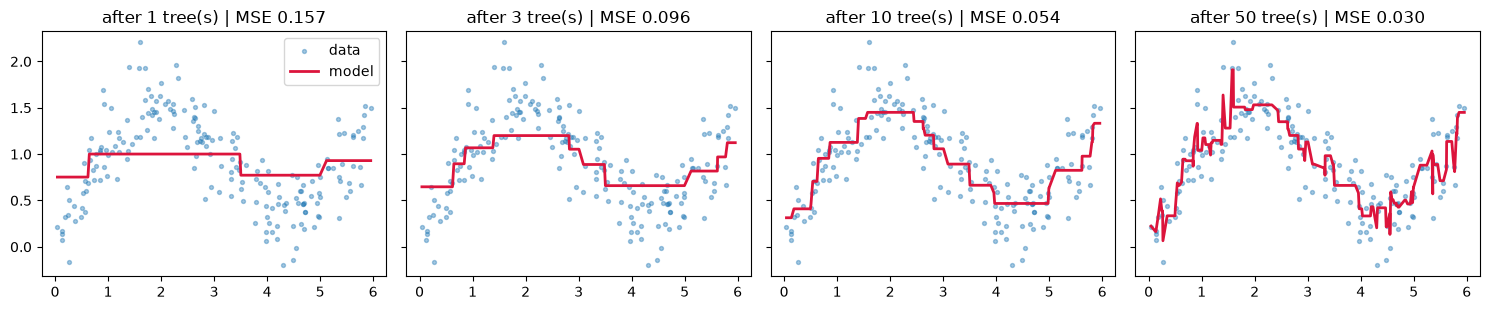

trees= 0  training MSE = 0.2236
trees= 1  training MSE = 0.1567
trees= 3  training MSE = 0.0957
trees=10  training MSE = 0.0544
trees=50  training MSE = 0.0303


In [6]:
x_toy = np.sort(rng.uniform(0, 6, 200))
y_toy = np.sin(x_toy) + 0.3 * x_toy + rng.normal(0, 0.25, size=200)
X_toy = x_toy.reshape(-1, 1)

eta = 0.3
F = np.full_like(y_toy, y_toy.mean())            # step 1: constant start
snapshots = {0: F.copy()}
for m in range(1, 51):
    residuals = y_toy - F                         # negative gradient of ½(y − F)²
    weak_tree = DecisionTreeRegressor(max_depth=2, random_state=SEED).fit(X_toy, residuals)
    F = F + eta * weak_tree.predict(X_toy)        # small step towards the residuals
    if m in (1, 3, 10, 50):
        snapshots[m] = F.copy()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, m in zip(axes, [1, 3, 10, 50]):
    ax.scatter(x_toy, y_toy, s=8, alpha=0.4, label="data")
    ax.plot(x_toy, snapshots[m], color="crimson", lw=2, label="model")
    ax.set_title(f"after {m} tree(s) | MSE {np.mean((y_toy - snapshots[m]) ** 2):.3f}")
axes[0].legend()
plt.tight_layout()
plt.show()

for m, pred in snapshots.items():
    print(f"trees={m:>2}  training MSE = {np.mean((y_toy - pred) ** 2):.4f}")

Each depth-2 tree can only draw 4 flat steps, yet 50 of them, each scaled by η = 0.3, trace the curve. The training MSE falls towards the noise level (the noise variance is 0.25² ≈ 0.06).

### ✍️ Your Turn

For **binary log-loss**, the negative gradient with respect to the raw score $F$ is $y - \sigma(F)$, where $\sigma(F) = 1/(1+e^{-F})$. Compute it for the three examples below (no loops).

In [7]:
y_bin = np.array([1.0, 0.0, 1.0])
raw_score = np.array([0.0, 0.0, 2.0])
neg_gradient = None  # TODO: your code here
check("neg_gradient", neg_gradient, [0.5, -0.5, 0.11920292],
      hint="sigmoid = 1 / (1 + np.exp(-raw_score)); then y_bin - sigmoid.")

⏳ neg_gradient: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_bin = np.array([1.0, 0.0, 1.0])
raw_score = np.array([0.0, 0.0, 2.0])
neg_gradient = y_bin - 1 / (1 + np.exp(-raw_score))
check("neg_gradient", neg_gradient, [0.5, -0.5, 0.11920292])
```

The third example is already confidently right ($p \approx 0.88$), so it gets a small "push". The next tree focuses on the examples that are still wrong.
</details>

> 💡 **Interview angle:** "How does gradient boosting work?" — start from a constant, then repeatedly fit a small tree to the **negative gradient of the loss** at the current predictions (the residuals, for squared error) and add it scaled by a learning rate. It is gradient descent where each step is a tree.

## 4. The XGBoost Objective: Gradients, Hessians, and Gain 🟡

XGBoost made boosting more principled with two ideas: **regularize the trees** and use a **second-order (Newton) approximation** of the loss.

**Objective when adding tree $f_t$:**

$$\text{Obj} = \sum_i \ell\big(y_i,\; \hat y_i^{(t-1)} + f_t(x_i)\big) + \Omega(f_t), \qquad \Omega(f) = \gamma T + \tfrac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

where $T$ is the number of leaves, $w_j$ the value in leaf $j$, $\lambda$ an L2 penalty on leaf values and $\gamma$ a penalty per leaf.

**Second-order Taylor expansion.** For every row, compute the **gradient** $g_i = \partial \ell / \partial \hat y$ and the **hessian** (second derivative) $h_i = \partial^2 \ell / \partial \hat y^2$ at the current prediction. Summing them over the rows in leaf $j$ gives $G_j = \sum g_i$ and $H_j = \sum h_i$, and the objective becomes a simple quadratic in each $w_j$:

$$\text{Obj} \approx \sum_j \Big[ G_j w_j + \tfrac{1}{2}(H_j + \lambda) w_j^2 \Big] + \gamma T$$

Setting the derivative to zero gives the **optimal leaf weight** and the best achievable objective:

$$w_j^* = -\frac{G_j}{H_j + \lambda}, \qquad \text{Obj}^* = -\frac{1}{2}\sum_j \frac{G_j^2}{H_j + \lambda} + \gamma T$$

**Split gain** — how much a split of a node into Left and Right improves the objective:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

| Loss | $g_i$ | $h_i$ |
|---|---|---|
| Squared error $\tfrac12(y-\hat y)^2$ | $\hat y - y$ | $1$ |
| Log-loss (raw score $F$, $p=\sigma(F)$) | $p - y$ | $p(1-p)$ |

**What the knobs do:** $\lambda$ shrinks leaf values towards 0 (most strongly when $H$ is small, i.e. few or very confident rows). $\gamma$ is the minimum gain a split must achieve, so it prunes weak splits. `min_child_weight` requires $H_j$ to be at least that large in every child.

> **Implementation detail (verified in 🔧 Build It From Scratch):** the installed XGBoost reports and prunes on the bracket **without the ½**, i.e. $\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda}$, and removes a split when that number is below `gamma`. The best split is the same either way; only the scale at which `gamma` bites changes.

In [8]:
def grad_hess(y, raw, loss):
    """Per-row gradient and hessian of the loss w.r.t. the raw prediction."""
    if loss == "squared_error":
        return raw - y, np.ones_like(y)
    p = 1 / (1 + np.exp(-raw))                 # log-loss
    return p - y, p * (1 - p)


def leaf_weight(G, H, lam):
    return -G / (H + lam)


# A leaf holding 3 regression rows with targets 3, 4, 5 and current prediction 0
g, h = grad_hess(np.array([3.0, 4.0, 5.0]), np.zeros(3), "squared_error")
print(f"squared error: G={g.sum():.1f}, H={h.sum():.1f}")
for lam in [0, 1, 10, 100]:
    print(f"  λ={lam:>3} → leaf weight {leaf_weight(g.sum(), h.sum(), lam):.3f}")
print("  (λ=0 gives the mean residual 4.0 — the plain gradient boosting answer)")

# A leaf holding 3 positive examples the model already predicts confidently (raw score 3 → p≈0.95)
g, h = grad_hess(np.ones(3), np.full(3, 3.0), "log_loss")
print(f"\nlog-loss, confident rows: G={g.sum():.4f}, H={h.sum():.4f}")
for lam in [0, 1]:
    print(f"  λ={lam} → leaf weight {leaf_weight(g.sum(), h.sum(), lam):.3f}")
print("  The hessian is tiny, so λ=1 dominates the denominator and shrinks the step by about 8×.")

squared error: G=-12.0, H=3.0
  λ=  0 → leaf weight 4.000
  λ=  1 → leaf weight 3.000
  λ= 10 → leaf weight 0.923
  λ=100 → leaf weight 0.117
  (λ=0 gives the mean residual 4.0 — the plain gradient boosting answer)

log-loss, confident rows: G=-0.1423, H=0.1355
  λ=0 → leaf weight 1.050
  λ=1 → leaf weight 0.125
  The hessian is tiny, so λ=1 dominates the denominator and shrinks the step by about 8×.


**Why second order?** The gradient says *which direction* to move. The hessian says *how curved* the loss is, so the step size fits the loss (a Newton step). One split-finding routine then works for **any** twice-differentiable loss: you only supply $g$ and $h$. With log-loss, rows that are already confident have small $h$ and small $g$, so they have little influence on the splits.

### ✍️ Your Turn

A leaf has gradient sum `G = -8`, hessian sum `H = 2`, and `reg_lambda = 2`. Compute the optimal leaf weight **with `leaf_weight`**, and also the gain of splitting a node with `G_L=-6, H_L=1` and `G_R=-2, H_R=1` (same λ, **XGBoost's implementation version without the ½**, γ = 0).

In [9]:
w_star = None     # TODO
split_gain = None  # TODO
check("w_star", w_star, 2.0, hint="-G / (H + lam)")
check("split_gain", split_gain, 36 / 3 + 4 / 3 - 64 / 4,
      hint="G_L²/(H_L+λ) + G_R²/(H_R+λ) − (G_L+G_R)²/(H_L+H_R+λ)")

⏳ w_star: not attempted yet — replace None with your answer.
⏳ split_gain: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
w_star = leaf_weight(-8, 2, 2)
GL, HL, GR, HR, lam = -6, 1, -2, 1, 2
split_gain = GL**2 / (HL + lam) + GR**2 / (HR + lam) - (GL + GR)**2 / (HL + HR + lam)
check("w_star", w_star, 2.0)
check("split_gain", split_gain, 36 / 3 + 4 / 3 - 64 / 4)
```

$36/3 + 4/3 - 64/4 = 12 + 1.33 - 16 = -2.67$. The gain is **negative**: with λ = 2, splitting such a tiny node makes the regularized objective *worse*, so XGBoost will not split it even with γ = 0. That is λ acting as a regularizer.
</details>

> 💡 **Interview angle:** "Derive XGBoost's leaf weight." — second-order Taylor expand the loss, sum $g$ and $h$ per leaf, add $\tfrac12\lambda w^2$, set the derivative to zero: $w^* = -G/(H+\lambda)$. Plugging back gives the score $-\tfrac12 G^2/(H+\lambda)$, and the split gain is left score + right score − parent score − γ.

## 5. Key Hyperparameters and Overfitting 🟡

The same ideas have different names in each library. Defaults below were read from the installed versions.

| What it controls | XGBoost | LightGBM | CatBoost | sklearn HGB |
|---|---|---|---|---|
| Step size per tree | `learning_rate` (0.3) | `learning_rate` (0.1) | `learning_rate` (auto) | `learning_rate` (0.1) |
| Number of trees | `n_estimators` | `n_estimators` | `iterations` (1000) | `max_iter` (100) |
| Tree size | `max_depth` (6), `max_leaves` | `num_leaves` (31), `max_depth` (−1 = no limit) | `depth` (6) | `max_leaf_nodes` (31), `max_depth` |
| Minimum leaf "size" | `min_child_weight` (1, hessian sum) | `min_child_samples` (20 rows), `min_child_weight` (1e-3) | `min_data_in_leaf` (non-symmetric trees only) | `min_samples_leaf` (20) |
| Row subsampling | `subsample` | `subsample` **+ `subsample_freq` > 0** | `subsample` / `bootstrap_type` | — |
| Column subsampling | `colsample_bytree` | `colsample_bytree` | `rsm` | `max_features` |
| L2 on leaf values (λ) | `reg_lambda` (1) | `reg_lambda` (0) | `l2_leaf_reg` (3) | `l2_regularization` (0) |
| L1 on leaf values (α) | `reg_alpha` (0) | `reg_alpha` (0) | — | — |
| Min gain to split (γ) | `gamma` (0) | `min_split_gain` (0) | — | — |

**Rules of thumb:**
- **`learning_rate` × `n_estimators` trade off.** A smaller learning rate needs more trees but usually generalizes a little better. Fix the learning rate and let **early stopping** pick the number of trees.
- **Tree size** (`max_depth` / `num_leaves`) sets how many features can interact. Deep trees overfit fast.
- **`min_child_weight` / `min_child_samples`, `subsample`, `colsample_bytree`, `reg_lambda`, `gamma`** all make each tree more conservative.

Let's *watch* overfitting: validation error curves for three XGBoost configurations. We carve a validation set out of the training data (the test set stays untouched).

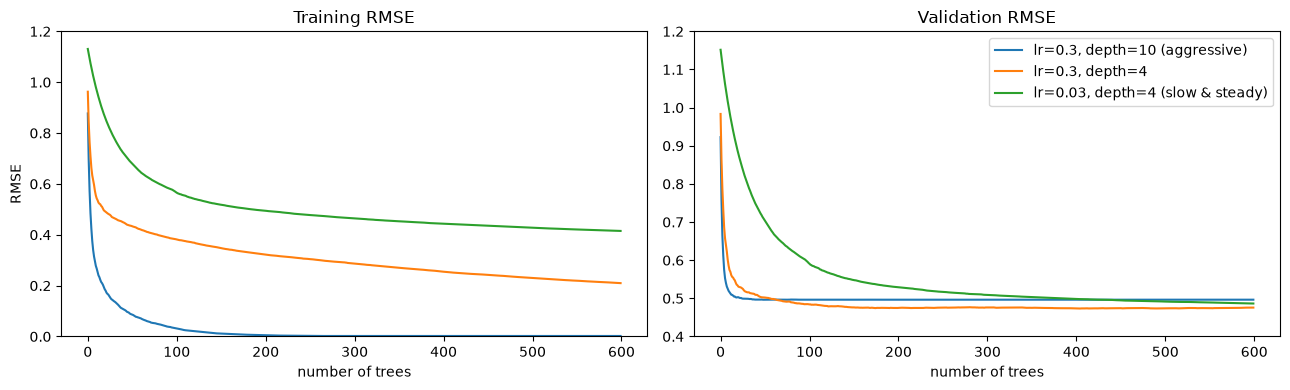

lr=0.3, depth=10 (aggressive)      best val RMSE 0.4963 at tree  75 | after 600 trees: val 0.4965 (+0.0002 vs best), train 0.0020
lr=0.3, depth=4                    best val RMSE 0.4733 at tree 404 | after 600 trees: val 0.4758 (+0.0025 vs best), train 0.2099
lr=0.03, depth=4 (slow & steady)   best val RMSE 0.4865 at tree 600 | after 600 trees: val 0.4865 (+0.0000 vs best), train 0.4151

Largest train/validation gap: 'lr=0.3, depth=10 (aggressive)' (train 0.0020 vs val 0.4965) → it memorized the training set.
Best validation RMSE: 'lr=0.3, depth=4'. 'lr=0.03, depth=4 (slow & steady)' was still improving at tree 600 → it needs more trees.


In [10]:
Xh_tr, Xh_val, yh_tr, yh_val = train_test_split(Xh_train, yh_train, test_size=0.25, random_state=SEED)

curve_configs = {
    "lr=0.3, depth=10 (aggressive)": dict(learning_rate=0.3, max_depth=10),
    "lr=0.3, depth=4": dict(learning_rate=0.3, max_depth=4),
    "lr=0.03, depth=4 (slow & steady)": dict(learning_rate=0.03, max_depth=4),
}
curves = {}
for name, params in curve_configs.items():
    model = xgb.XGBRegressor(n_estimators=600, eval_metric="rmse", random_state=SEED, **params)
    model.fit(Xh_tr, yh_tr, eval_set=[(Xh_tr, yh_tr), (Xh_val, yh_val)], verbose=False)
    history = model.evals_result()
    curves[name] = (np.array(history["validation_0"]["rmse"]), np.array(history["validation_1"]["rmse"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, (train_curve, val_curve) in curves.items():
    axes[0].plot(train_curve, label=name)
    axes[1].plot(val_curve, label=name)
axes[0].set(title="Training RMSE", xlabel="number of trees", ylabel="RMSE", ylim=(0, 1.2))
axes[1].set(title="Validation RMSE", xlabel="number of trees", ylim=(0.4, 1.2))
axes[1].legend()
plt.tight_layout()
plt.show()

curve_summary = {}
for name, (train_curve, val_curve) in curves.items():
    best = int(np.argmin(val_curve))
    curve_summary[name] = {"best tree": best + 1, "best val": val_curve[best], "val@600": val_curve[-1],
                           "train@600": train_curve[-1], "train-val gap": val_curve[-1] - train_curve[-1]}
    print(f"{name:34s} best val RMSE {val_curve[best]:.4f} at tree {best + 1:>3} | after 600 trees: "
          f"val {val_curve[-1]:.4f} (+{val_curve[-1] - val_curve[best]:.4f} vs best), train {train_curve[-1]:.4f}")

curve_df = pd.DataFrame(curve_summary).T
most_overfit = curve_df["train-val gap"].idxmax()
best_config = curve_df["best val"].idxmin()
print(f"\nLargest train/validation gap: '{most_overfit}' (train {curve_df.loc[most_overfit, 'train@600']:.4f} "
      f"vs val {curve_df.loc[most_overfit, 'val@600']:.4f}) → it memorized the training set.")
print(f"Best validation RMSE: '{best_config}'. "
      f"'{curve_df['best tree'].idxmax()}' was still improving at tree {int(curve_df['best tree'].max())} → it needs more trees.")

How to read these curves:
- **Training RMSE always goes down** as trees are added. It says nothing about generalization.
- The **aggressive** model (deep trees, big steps) drives training error to almost zero and its validation error stops improving early, at a worse level than the shallower models. The huge train/validation gap is the signature of **overfitting**. (Once the training residuals are ~0, new trees have nothing left to fit, so the validation curve goes flat rather than shooting up.)
- The **slow** model (small learning rate) is still improving at the end: it needs many more trees. This is why you fix the learning rate and let **early stopping** choose the count.

Now let's see how the "conservative" knobs change the aggressive depth-10 model (300 trees each). Not every knob helps every model — check the table.

In [11]:
regularization_configs = {
    "no extra regularization": {},
    "min_child_weight=20": dict(min_child_weight=20),
    "subsample=0.7, colsample_bytree=0.7": dict(subsample=0.7, colsample_bytree=0.7),
    "reg_lambda=50": dict(reg_lambda=50),
    "gamma=0.05": dict(gamma=0.05),
    "all of the above": dict(min_child_weight=20, subsample=0.7, colsample_bytree=0.7, reg_lambda=50, gamma=0.05),
}
reg_rows = []
for name, params in regularization_configs.items():
    model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.3, max_depth=10, random_state=SEED, **params)
    model.fit(Xh_tr, yh_tr)
    reg_rows.append({"config": name,
                     "train RMSE": root_mean_squared_error(yh_tr, model.predict(Xh_tr)),
                     "val RMSE": root_mean_squared_error(yh_val, model.predict(Xh_val))})
reg_table = pd.DataFrame(reg_rows).set_index("config")
reg_table["gap"] = reg_table["val RMSE"] - reg_table["train RMSE"]
print(reg_table.round(4))
best_reg = reg_table["val RMSE"].idxmin()
print(f"\nLowest validation RMSE: '{best_reg}' "
      f"({reg_table.loc['no extra regularization', 'val RMSE'] - reg_table.loc[best_reg, 'val RMSE']:.4f} better than no regularization)")

                                     train RMSE  val RMSE     gap
config                                                           
no extra regularization                  0.0020    0.4965  0.4945
min_child_weight=20                      0.0554    0.4905  0.4352
subsample=0.7, colsample_bytree=0.7      0.0009    0.5219  0.5211
reg_lambda=50                            0.0559    0.4728  0.4169
gamma=0.05                               0.1632    0.4969  0.3337
all of the above                         0.1633    0.4829  0.3197

Lowest validation RMSE: 'reg_lambda=50' (0.0237 better than no regularization)


### ✍️ Your Turn

LightGBM grows trees by **number of leaves**, XGBoost (by default) by **depth**. What is the **smallest `max_depth`** whose full depth-wise tree can hold LightGBM's default `num_leaves=31`? Compute it (don't hard-code it).

In [12]:
num_leaves = 31
depth_needed = None  # TODO: smallest integer d with 2**d >= num_leaves
check("depth_needed", depth_needed, 5, hint="np.ceil(np.log2(num_leaves)), converted to int.")

⏳ depth_needed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
num_leaves = 31
depth_needed = int(np.ceil(np.log2(num_leaves)))
check("depth_needed", depth_needed, 5)
```

A depth-5 tree holds up to 32 leaves. A leaf-wise tree with 31 leaves can be much **deeper** than 5 on one side, which is why LightGBM users also cap `max_depth` or raise `min_child_samples` on small data.
</details>

> 💡 **Interview angle:** "Your GBM overfits — what do you change?" — lower `learning_rate` with early stopping, shrink trees (`max_depth`/`num_leaves`), raise `min_child_weight`/`min_child_samples`, add `subsample`/`colsample_bytree`, increase `reg_lambda`/`gamma`. Then say you'd confirm it on a **validation** curve, not the test set.

## 6. Early Stopping on a Validation Set 🟡

**Early stopping** keeps adding trees while a **validation** metric improves, and stops after `N` rounds (the *patience*) without improvement. The model then uses the best number of trees.

```
 train ─┬──────────────── fit trees
 val   ─┴── watch the metric after every tree → choose the number of trees
 test  ──── touched ONCE at the very end → honest score
```

⚠️ **Never early-stop on the test set.** Picking the number of trees by test performance is *tuning on the test set*: the reported score is optimistic (see ⚠️ Pitfall 1).

| Library | How to early-stop | Best iteration attribute |
|---|---|---|
| XGBoost | `XGBRegressor(early_stopping_rounds=50)`, `fit(..., eval_set=[(X_val, y_val)])` | `best_iteration` (0-based) |
| LightGBM | `fit(..., eval_X=X_val, eval_y=y_val, callbacks=[lgb.early_stopping(50)])` | `best_iteration_` (= number of trees) |
| CatBoost | `fit(..., eval_set=(X_val, y_val), early_stopping_rounds=50)` | `get_best_iteration()` (0-based) |
| sklearn HGB | `early_stopping=True` (carves `validation_fraction` out of the training data) | `n_iter_` |

In [13]:
es_model = xgb.XGBRegressor(n_estimators=5000, learning_rate=0.05, max_depth=6, eval_metric="rmse",
                            early_stopping_rounds=50, random_state=SEED)
start = time.perf_counter()
es_model.fit(Xh_tr, yh_tr, eval_set=[(Xh_val, yh_val)], verbose=False)
print(f"stopped after {es_model.get_booster().num_boosted_rounds()} trees in {time.perf_counter() - start:.1f}s; "
      f"best_iteration={es_model.best_iteration} (0-based) with val RMSE {es_model.best_score:.4f}")

# predict() automatically uses only the trees up to best_iteration
auto = es_model.predict(Xh_val)
explicit = es_model.predict(Xh_val, iteration_range=(0, es_model.best_iteration + 1))
print("predict() uses the best iteration:", np.allclose(auto, explicit))
print(f"validation RMSE {root_mean_squared_error(yh_val, auto):.4f}")

stopped after 1096 trees in 4.0s; best_iteration=1045 (0-based) with val RMSE 0.4623
predict() uses the best iteration: True
validation RMSE 0.4623


### ✍️ Your Turn

Implement early stopping yourself. Given a list of validation losses (one per tree) and a `patience`, return `(best_index, stopped_at)`: the index of the lowest loss so far, and the index at which training stops because `patience` rounds passed with no new best. If it never stops, `stopped_at` is the last index.

In [14]:
val_losses = [0.90, 0.72, 0.65, 0.66, 0.64, 0.67, 0.68, 0.69, 0.70]


def early_stop(losses, patience):
    # TODO: return (best_index, stopped_at)
    return None


check("early_stop", early_stop(val_losses, patience=3), (4, 7),
      hint="Track best_index; stop when i - best_index >= patience.")

⏳ early_stop: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
val_losses = [0.90, 0.72, 0.65, 0.66, 0.64, 0.67, 0.68, 0.69, 0.70]


def early_stop(losses, patience):
    best_index, best_loss = 0, losses[0]
    for i, loss in enumerate(losses):
        if loss < best_loss:
            best_index, best_loss = i, loss
        elif i - best_index >= patience:
            return best_index, i
    return best_index, len(losses) - 1


check("early_stop", early_stop(val_losses, patience=3), (4, 7))
```

The small bump at index 3 did not stop training because patience was 3; the new best at index 4 reset the counter.
</details>

> 💡 **Interview angle:** "How do you choose the number of trees?" — fix a learning rate and early-stop on a validation set (or inside each CV fold). For the final model you can retrain on train+validation with roughly that number of trees (often scaled up a little for the extra data). Never use the test set.

## 7. XGBoost in Practice 🟡

Now a real classification problem: the **Adult census income** dataset from OpenML (1994 US Census). Predict whether a person earns **more than \$50K a year**. It is a good example of real-world tabular data:
- **categorical columns** (`workclass`, `education`, `occupation`, …),
- **missing values** (in `workclass`, `occupation`, `native-country`),
- **class imbalance** (only about 1 in 4 people earn >\$50K).

We split once into **train (60%) / validation (20%) / test (20%)** with stratification. Sections 7–12 use only train and validation. The test set is used exactly once, at the end of the 🚀 Mini Project.

In [15]:
adult = fetch_openml("adult", version=2, as_frame=True)
X_adult = adult.data
y_adult = (adult.target == ">50K").astype(int)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_adult, y_adult, test_size=0.4, stratify=y_adult, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)

cat_cols = X_adult.select_dtypes("category").columns.tolist()
num_cols = [c for c in X_adult.columns if c not in cat_cols]
print(f"rows: {len(X_adult):,} | train {len(X_tr):,} · val {len(X_val):,} · test {len(X_test):,}")
print(f"positive rate (>50K): {y_adult.mean():.1%}")
print("categorical:", cat_cols)
print("numeric    :", num_cols)
print("missing values per column:\n", X_adult.isna().sum()[lambda s: s > 0])

rows: 48,842 | train 29,305 · val 9,768 · test 9,769
positive rate (>50K): 23.9%
categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numeric    : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
missing values per column:
 workclass         2799
occupation        2809
native-country     857
dtype: int64


### 7a. Native categoricals, missing values and the histogram method

- **`tree_method="hist"`** (the default since XGBoost 2.0) buckets each feature into at most `max_bin=256` bins and finds splits on the bucket histograms. This is much faster than trying every unique value (`"exact"`).
- **`enable_categorical=True`** lets XGBoost read pandas `category` columns directly. **No one-hot or label encoding is needed.** Features with fewer than `max_cat_to_onehot` (default 4) categories use one-vs-rest splits. Larger ones are *partitioned*: categories are sorted by their gradient statistics and split into two groups.
- **Missing values**: XGBoost learns a **default direction** for NaN at every split (whichever side lowers the loss). No imputation is needed.

In [16]:
xgb_adult = xgb.XGBClassifier(n_estimators=3000, learning_rate=0.05, max_depth=6, enable_categorical=True,
                              eval_metric="logloss", early_stopping_rounds=50, random_state=SEED)
start = time.perf_counter()
xgb_adult.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_seconds = time.perf_counter() - start

p_val_xgb = xgb_adult.predict_proba(X_val)[:, 1]
config = json.loads(xgb_adult.get_booster().save_config())
print(f"trained on raw pandas categories + NaN in {xgb_seconds:.1f}s | best_iteration={xgb_adult.best_iteration}")
print("tree updater used:", config["learner"]["gradient_booster"]["updater"][0]["name"], "(= the histogram method)")
print(f"validation ROC-AUC {roc_auc_score(y_val, p_val_xgb):.4f} | log-loss {log_loss(y_val, p_val_xgb):.4f}")

trained on raw pandas categories + NaN in 1.1s | best_iteration=212
tree updater used: grow_quantile_histmaker (= the histogram method)
validation ROC-AUC 0.9298 | log-loss 0.2742


In [17]:
# How missing values are routed: a tiny 1-feature example where x=1 is missing
X_small = np.array([[np.nan], [2.0], [3.0], [4.0], [5.0], [6.0]])
y_small = np.array([1.0, 1.5, 2.0, 6.0, 7.0, 7.5])
tiny = xgb.XGBRegressor(n_estimators=1, max_depth=1, learning_rate=1.0, base_score=0.0).fit(X_small, y_small)
print(tiny.get_booster().get_dump(with_stats=True)[0])
print("prediction for a NaN input:", tiny.predict(np.array([[np.nan]])))
print("→ 'missing=1' means NaN goes to node 1 (the left, low-target branch), learned from the data")

0:[f0<4] yes=1,no=2,missing=1,gain=20.8392868,cover=6
	1:leaf=1.125,cover=3
	2:leaf=5.125,cover=3

prediction for a NaN input: [1.125]
→ 'missing=1' means NaN goes to node 1 (the left, low-target branch), learned from the data


### 7b. Class imbalance with `scale_pos_weight`

`scale_pos_weight` multiplies the gradient and hessian of positive rows. A common starting value is `count(negatives) / count(positives)`. Let's see what it actually changes.

In [18]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
imbalance_rows = []
for label, weight in [("default", 1.0), (f"scale_pos_weight={spw:.2f}", spw)]:
    model = xgb.XGBClassifier(n_estimators=3000, learning_rate=0.05, max_depth=6, enable_categorical=True,
                              eval_metric="logloss", early_stopping_rounds=50, scale_pos_weight=weight,
                              random_state=SEED)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    imbalance_rows.append({"model": label, "ROC-AUC": roc_auc_score(y_val, proba), "log-loss": log_loss(y_val, proba),
                           "precision@0.5": precision_score(y_val, pred), "recall@0.5": recall_score(y_val, pred),
                           "mean predicted p": proba.mean()})
imbalance_table = pd.DataFrame(imbalance_rows).set_index("model")
print(imbalance_table.round(4))
print(f"actual positive rate on validation: {y_val.mean():.4f}")
d = imbalance_table.iloc[1] - imbalance_table.iloc[0]
print(f"\nWeighting changed ROC-AUC by {d['ROC-AUC']:+.4f}, recall by {d['recall@0.5']:+.3f}, "
      f"precision by {d['precision@0.5']:+.3f}, and log-loss by {d['log-loss']:+.4f}.")
print("→ Ranking quality barely moves; weighting mostly shifts probabilities upwards (hurting calibration)."
      if abs(d["ROC-AUC"]) < 0.005 and d["log-loss"] > 0 else "→ Inspect the table: the effect differs from the usual pattern here.")

                       ROC-AUC  log-loss  precision@0.5  recall@0.5  \
model                                                                 
default                 0.9298    0.2742         0.7854      0.6624   
scale_pos_weight=3.18   0.9279    0.3232         0.6171      0.8434   

                       mean predicted p  
model                                    
default                          0.2390  
scale_pos_weight=3.18            0.3307  
actual positive rate on validation: 0.2393

Weighting changed ROC-AUC by -0.0019, recall by +0.181, precision by -0.168, and log-loss by +0.0490.
→ Ranking quality barely moves; weighting mostly shifts probabilities upwards (hurting calibration).


**Lesson:** for a ranking metric like ROC-AUC, class weights rarely matter. If you need a particular recall, it is often cleaner to keep the model unweighted (calibrated probabilities) and **tune the decision threshold on the validation set**.

### 7c. Monotonic constraints

Sometimes domain knowledge says *"more income should never lower the predicted house price"*. `monotone_constraints` forces the model to respect that. This is common in credit scoring, where regulators ask for it.

unconstrained     val RMSE 0.4791 | price ever decreases as income rises: True
monotone MedInc↑  val RMSE 0.5179 | price ever decreases as income rises: False
→ the constraint changed validation RMSE by +0.0388: a price paid for guaranteed, explainable behaviour.


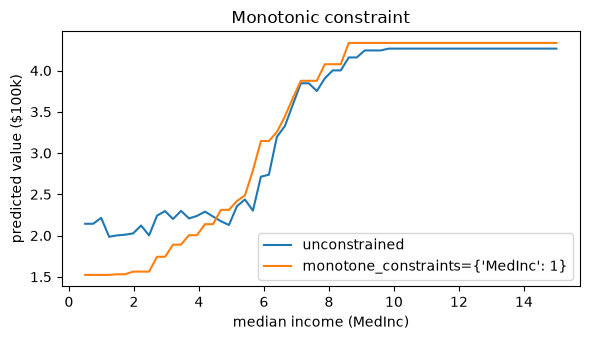

In [19]:
grid = pd.concat([Xh_tr.median().to_frame().T] * 60, ignore_index=True)   # one "typical" district, 60 times
grid["MedInc"] = np.linspace(0.5, 15, 60)                                   # sweep only median income

free_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, random_state=SEED).fit(Xh_tr, yh_tr)
mono_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, monotone_constraints={"MedInc": 1},
                              random_state=SEED).fit(Xh_tr, yh_tr)

mono_rmse = {}
for name, model in [("unconstrained", free_model), ("monotone MedInc↑", mono_model)]:
    curve = model.predict(grid)
    mono_rmse[name] = root_mean_squared_error(yh_val, model.predict(Xh_val))
    print(f"{name:17s} val RMSE {mono_rmse[name]:.4f} | "
          f"price ever decreases as income rises: {bool(np.any(np.diff(curve) < -1e-6))}")
cost = mono_rmse["monotone MedInc↑"] - mono_rmse["unconstrained"]
print(f"→ the constraint changed validation RMSE by {cost:+.4f}: "
      + ("a price paid for guaranteed, explainable behaviour." if cost > 0 else "no accuracy cost here."))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(grid["MedInc"], free_model.predict(grid), label="unconstrained")
ax.plot(grid["MedInc"], mono_model.predict(grid), label="monotone_constraints={'MedInc': 1}")
ax.set(xlabel="median income (MedInc)", ylabel="predicted value ($100k)", title="Monotonic constraint")
ax.legend()
plt.tight_layout()
plt.show()

### 7d. Built-in importance types disagree

`booster.get_score(importance_type=...)`:
- **`weight`**: how many times a feature is used to split.
- **`gain`**: the *average* gain of those splits. **`total_gain`** = gain × weight.
- **`cover`**: the average hessian sum (≈ number of rows, for squared error) of those splits.

In [20]:
booster = xgb_adult.get_booster()
importance = pd.DataFrame({t: pd.Series(booster.get_score(importance_type=t))
                           for t in ["weight", "gain", "cover", "total_gain"]})
ranks = importance.rank(ascending=False).astype(int)
print("rank of each feature under each importance type (1 = most important):")
print(ranks.sort_values("total_gain"))
top_by_type = {t: importance[t].idxmax() for t in importance.columns}
print("\ntop feature per type:", top_by_type)

rank of each feature under each importance type (1 = most important):
                weight  gain  cover  total_gain
relationship        10     1      7           1
marital-status      11     2      4           2
capital-gain         5     3      1           3
education            2     4     11           4
occupation           1     6     13           5
age                  3     7      8           6
capital-loss         6     5      3           7
hours-per-week       8     8      5           8
native-country       7    10      9           9
workclass            9    11     12          10
fnlwgt               4    13     10          11
sex                 13     9      6          12
race                12    12      2          13
education-num       14    14     14          14

top feature per type: {'weight': 'occupation', 'gain': 'relationship', 'cover': 'capital-gain', 'total_gain': 'relationship'}


The rankings differ a lot. `weight` favours continuous features with many possible thresholds (like `fnlwgt`, a census sampling weight), even when those splits add little. Section 11 shows a more reliable alternative: SHAP.

### ✍️ Your Turn

A fraud dataset has the labels below. Compute the usual starting value for `scale_pos_weight`.

In [21]:
labels = np.array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])
scale_pos_weight = None  # TODO
check("scale_pos_weight", scale_pos_weight, 5.0, hint="count of 0s divided by count of 1s")

⏳ scale_pos_weight: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
labels = np.array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])
scale_pos_weight = (labels == 0).sum() / (labels == 1).sum()
check("scale_pos_weight", scale_pos_weight, 5.0)
```
</details>

> 💡 **Interview angle:** "Does XGBoost need one-hot encoding or imputation?" — no: with `enable_categorical=True` it splits pandas categories natively, and it learns a default direction for missing values at each split. Mention `tree_method="hist"` as the default and `scale_pos_weight` / threshold tuning for imbalance.

## 8. LightGBM in Practice 🟡

LightGBM (Microsoft, 2017) was designed for speed on large data. Its key ideas:

**1. Leaf-wise (best-first) growth.** XGBoost's default grows trees *level by level*. LightGBM always splits the single leaf with the **largest loss reduction**:

```
 Level-wise (XGBoost default, depth 2)       Leaf-wise (LightGBM, 4 leaves)
           ●                                         ●
         /   \                                     /   \
        ●     ●        ← every node split          ○     ●
       / \   / \                                        / \
      ○   ○ ○   ○                                      ○   ●     ← keeps splitting where the
                                                           / \       loss drops most
                                                          ○   ○
```
For the same number of leaves, leaf-wise usually reaches a lower loss but can grow **deep, lopsided** trees that overfit small data. Control it with `num_leaves`, `min_child_samples`, and `max_depth`. (XGBoost can do the same with `grow_policy="lossguide"`.)

**2. Histograms.** Like XGBoost's `hist`: features are bucketed (`max_bin=255`). A child's histogram is computed as *parent − sibling*, which halves the work.

**3. GOSS (Gradient-based One-Side Sampling).** Rows with large gradients are the ones still badly predicted. GOSS keeps the top `top_rate=20%` rows by |gradient|, randomly samples `other_rate=10%` of the rest, and up-weights that sample so the gain estimate stays unbiased. Turn it on with `data_sample_strategy="goss"`.

**4. EFB (Exclusive Feature Bundling).** Sparse features that are rarely non-zero at the same time (e.g. one-hot columns) are bundled into a single feature, which cuts the feature count. It is on by default (`enable_bundle=True`).

**5. Native categoricals.** pandas `category` columns are detected automatically. For a feature with at most `max_cat_to_onehot=4` categories it uses one-vs-rest splits. Otherwise it **sorts the categories by (sum of gradients / sum of hessians)** and finds the best split point along that order, regularized by `cat_smooth`, `cat_l2`, `min_data_per_group` and `max_cat_threshold`. It does **not** one-hot encode.

### 8a. Native API: `lgb.train` with callbacks

In [22]:
train_set = lgb.Dataset(X_tr, label=y_tr)                      # category columns detected automatically
val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)  # reference → reuse the training bins

params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.05,
          "num_leaves": 31, "verbose": -1, "seed": SEED}
eval_history = {}
start = time.perf_counter()
lgb_booster = lgb.train(
    params, train_set, num_boost_round=3000, valid_sets=[val_set], valid_names=["val"],
    callbacks=[lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False),
               lgb.record_evaluation(eval_history)],        # replaces the removed evals_result= argument
)
print(f"lgb.train: best_iteration={lgb_booster.best_iteration} in {time.perf_counter() - start:.1f}s")
print("recorded metrics:", {k: len(v) for k, v in eval_history["val"].items()}, "values each")
print(f"best val log-loss {lgb_booster.best_score['val']['binary_logloss']:.4f} | AUC {lgb_booster.best_score['val']['auc']:.4f}")
print("categorical features used:", lgb_booster.pandas_categorical is not None)

lgb.train: best_iteration=248 in 3.6s
recorded metrics: {'binary_logloss': 298, 'auc': 298} values each
best val log-loss 0.2742 | AUC 0.9297
categorical features used: True


### 8b. scikit-learn API (LightGBM ≥ 4.7 uses `eval_X` / `eval_y`)

In [23]:
lgb_sk = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, num_leaves=31, verbose=-1, random_state=SEED)
start = time.perf_counter()
lgb_sk.fit(X_tr, y_tr, eval_X=X_val, eval_y=y_val, eval_metric="binary_logloss",
           callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_seconds = time.perf_counter() - start
p_val_lgb = lgb_sk.predict_proba(X_val)[:, 1]
print(f"LGBMClassifier: best_iteration_={lgb_sk.best_iteration_} in {lgb_seconds:.1f}s | "
      f"val AUC {roc_auc_score(y_val, p_val_lgb):.4f} | log-loss {log_loss(y_val, p_val_lgb):.4f}")

# GOSS: same settings, gradient-based sampling
goss = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, num_leaves=31, data_sample_strategy="goss",
                          verbose=-1, random_state=SEED)
start = time.perf_counter()
goss.fit(X_tr, y_tr, eval_X=X_val, eval_y=y_val, callbacks=[lgb.early_stopping(50, verbose=False)])
goss_seconds = time.perf_counter() - start
print(f"GOSS          : best_iteration_={goss.best_iteration_} in {goss_seconds:.1f}s | "
      f"val AUC {roc_auc_score(y_val, goss.predict_proba(X_val)[:, 1]):.4f}")
print("→ GOSS was", "faster" if goss_seconds < lgb_seconds else "not faster",
      "here; its speed-up matters most with millions of rows.")

LGBMClassifier: best_iteration_=248 in 3.7s | val AUC 0.9297 | log-loss 0.2742


GOSS          : best_iteration_=285 in 4.8s | val AUC 0.9268
→ GOSS was not faster here; its speed-up matters most with millions of rows.


In [24]:
# num_leaves vs max_depth: max_depth caps the tree even if num_leaves allows more
capped = lgb.LGBMClassifier(n_estimators=3, num_leaves=31, max_depth=3, verbose=-1, random_state=SEED).fit(X_tr, y_tr)
print("leaves per tree with num_leaves=31, max_depth=3:",
      [t["num_leaves"] for t in capped.booster_.dump_model()["tree_info"]])

leaves per tree with num_leaves=31, max_depth=3: [8, 8, 8]


### ✍️ Your Turn

In LightGBM, `subsample` (alias `bagging_fraction`) **does nothing unless `subsample_freq` (alias `bagging_freq`) is > 0**. Fill `my_bagging_params` with values that really turn on 70% row bagging at every iteration. The checker trains a model with your params and confirms its predictions differ from the no-bagging model.

In [25]:
my_bagging_params = None  # TODO: a dict for LGBMClassifier, e.g. {"subsample": ..., "subsample_freq": ...}

X_numeric_tr = X_tr[num_cols]
no_bagging = lgb.LGBMClassifier(n_estimators=30, verbose=-1, random_state=SEED).fit(X_numeric_tr, y_tr)
bagging_really_on = None
if my_bagging_params is not None:
    yours = lgb.LGBMClassifier(n_estimators=30, verbose=-1, random_state=SEED, **my_bagging_params).fit(X_numeric_tr, y_tr)
    bagging_really_on = (not np.array_equal(yours.predict_proba(X_numeric_tr), no_bagging.predict_proba(X_numeric_tr))
                         and yours.get_params().get("subsample") == 0.7)
check("bagging_really_on", bagging_really_on, True, hint="Set subsample=0.7 AND subsample_freq=1.")

⏳ bagging_really_on: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
my_bagging_params = {"subsample": 0.7, "subsample_freq": 1}

X_numeric_tr = X_tr[num_cols]
no_bagging = lgb.LGBMClassifier(n_estimators=30, verbose=-1, random_state=SEED).fit(X_numeric_tr, y_tr)
yours = lgb.LGBMClassifier(n_estimators=30, verbose=-1, random_state=SEED, **my_bagging_params).fit(X_numeric_tr, y_tr)
bagging_really_on = (not np.array_equal(yours.predict_proba(X_numeric_tr), no_bagging.predict_proba(X_numeric_tr))
                     and yours.get_params().get("subsample") == 0.7)
check("bagging_really_on", bagging_really_on, True)
```

`subsample_freq=k` re-draws the bagged rows every `k` iterations. With the default `0`, LightGBM silently ignores `subsample`.
</details>

> 💡 **Interview angle:** "LightGBM vs XGBoost?" — LightGBM grows leaf-wise (lower loss per leaf, more overfitting risk on small data), and adds GOSS and EFB for speed on big, sparse data. Today both use histograms and native categoricals, so accuracy is usually close. The real differences are defaults, speed profile, and API details (e.g. `subsample_freq`).

## 9. CatBoost in Practice 🟡

CatBoost (Yandex, 2017) is built around **categorical features** and a subtle bug in ordinary boosting called **prediction shift**.

### 9a. The problem: target leakage in target encoding

**Target encoding** replaces a category with the average target for that category (e.g. `occupation="Exec-managerial"` → 0.48). If a row's **own label** is included in that average, the feature leaks the answer. This is worst for rare categories: a category seen once is encoded as exactly its own label.

**CatBoost's fix — ordered target statistics.** Shuffle the rows into a random order (a *permutation*, like a timeline). Encode each row using **only the rows before it**:

$$\text{TS}_i = \frac{\sum_{j<i,\; c_j = c_i} y_j \;+\; a \cdot p}{\#\{j<i : c_j = c_i\} \;+\; a}$$

where $p$ is a prior (e.g. the overall positive rate) and $a$ its weight. No row ever sees its own label. CatBoost uses several permutations, and at prediction time uses statistics from all training data.

**Ordered boosting** applies the same "only look at the past" idea to the residuals: in plain boosting, a row's gradient is computed by a model that was trained on that same row, which biases the gradients (*prediction shift*). `boosting_type="Ordered"` fixes this with models trained on prefixes of the permutation (slower; helps most on small data). `"Plain"` keeps ordinary boosting, but categorical features still get ordered target statistics.

**Symmetric (oblivious) trees.** By default (`grow_policy="SymmetricTree"`) every node on the same level uses the **same split**. That regularizes the model and makes prediction extremely fast: a depth-6 tree is just 6 comparisons that form a 6-bit index into 64 leaf values.

Let's *measure* the leakage with a **pure-noise ID column** we add ourselves: 5,000 random "customer IDs" that have nothing to do with income.

In [26]:
id_train = rng.integers(0, 5000, len(X_tr)).astype(str)
id_val = rng.integers(0, 5000, len(X_val)).astype(str)
prior = y_tr.mean()

# ❌ Naive target encoding: mean target per ID, computed on the full training set (includes each row's own label)
naive_means = pd.Series(y_tr.to_numpy()).groupby(id_train).mean()
naive_train = pd.Series(id_train).map(naive_means).to_numpy()
naive_val = pd.Series(id_val).map(naive_means).fillna(prior).to_numpy()

# ✅ Ordered target statistics: only rows earlier in a random permutation
order = rng.permutation(len(X_tr))
frame = pd.DataFrame({"id": id_train[order], "y": y_tr.to_numpy()[order]})
prev_sum = frame.groupby("id")["y"].cumsum() - frame["y"]       # sum of labels of EARLIER rows with this ID
prev_count = frame.groupby("id").cumcount()                      # number of EARLIER rows with this ID
ordered_ts = np.empty(len(X_tr))
ordered_ts[order] = ((prev_sum + 1.0 * prior) / (prev_count + 1.0)).to_numpy()

print(f"noise ID, naive encoding  : train AUC {roc_auc_score(y_tr, naive_train):.3f} | val AUC {roc_auc_score(y_val, naive_val):.3f}")
print(f"noise ID, ordered TS      : train AUC {roc_auc_score(y_tr, ordered_ts):.3f}  (honest: no signal, as it should be)")

noise ID, naive encoding  : train AUC 0.769 | val AUC 0.493
noise ID, ordered TS      : train AUC 0.502  (honest: no signal, as it should be)


The naive encoding makes pure noise look predictive on the training set (AUC well above 0.5), yet it is useless on validation. A model trained on it will trust a fake feature (⚠️ Pitfall 4 shows the damage). Ordered statistics correctly show "no signal".

### 9b. Training CatBoost with `Pool` and `cat_features`

CatBoost needs categorical values as **strings or integers**. A `NaN` inside a categorical column raises an error, so we map it to an explicit `"missing"` category (numeric NaNs are fine: `nan_mode="Min"` by default).

In [27]:
def fill_missing_categories(df):
    """CatBoost needs str/int categories: turn NaN into an explicit 'missing' category."""
    out = df.copy()
    for col in cat_cols:
        out[col] = out[col].cat.add_categories("missing").fillna("missing")
    return out


train_pool = Pool(fill_missing_categories(X_tr), y_tr, cat_features=cat_cols)
val_pool = Pool(fill_missing_categories(X_val), y_val, cat_features=cat_cols)

cb_model = CatBoostClassifier(iterations=3000, learning_rate=0.08, depth=6, eval_metric="Logloss",
                              random_seed=SEED, verbose=0, allow_writing_files=False)
start = time.perf_counter()
cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)   # use_best_model=True by default with eval_set
cb_seconds = time.perf_counter() - start
p_val_cb = cb_model.predict_proba(val_pool)[:, 1]
all_params = cb_model.get_all_params()
print(f"CatBoost: best iteration {cb_model.get_best_iteration()} (0-based), trees kept {cb_model.tree_count_}, {cb_seconds:.1f}s")
print(f"val AUC {roc_auc_score(y_val, p_val_cb):.4f} | log-loss {log_loss(y_val, p_val_cb):.4f}")
print("grow_policy:", all_params["grow_policy"], "| boosting_type:", all_params["boosting_type"],
      "| l2_leaf_reg:", all_params["l2_leaf_reg"], "| one_hot_max_size:", all_params.get("one_hot_max_size"))

CatBoost: best iteration 456 (0-based), trees kept 457, 6.2s
val AUC 0.9305 | log-loss 0.2734
grow_policy: SymmetricTree | boosting_type: Plain | l2_leaf_reg: 3 | one_hot_max_size: 2


### ✍️ Your Turn

Compute ordered target statistics **by hand** for this tiny sequence (already in permutation order), with prior `p = 0.5` and weight `a = 1`. Row 0 has no history, so it gets $(0 + 0.5)/(0 + 1) = 0.5$.

In [28]:
categories = ["a", "b", "a", "a", "b"]
targets = [1, 0, 0, 1, 1]
ordered_stats = None  # TODO: a list of 5 numbers
check("ordered_stats", ordered_stats, [0.5, 0.5, 0.75, 0.5, 0.25],
      hint="For each row: (sum of earlier targets with the same category + 0.5) / (count of earlier same-category rows + 1)")

⏳ ordered_stats: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
categories = ["a", "b", "a", "a", "b"]
targets = [1, 0, 0, 1, 1]
sums, counts, ordered_stats = {}, {}, []
for cat, target in zip(categories, targets):
    ordered_stats.append((sums.get(cat, 0) + 0.5) / (counts.get(cat, 0) + 1))
    sums[cat] = sums.get(cat, 0) + target       # update AFTER encoding → no self-leakage
    counts[cat] = counts.get(cat, 0) + 1
check("ordered_stats", ordered_stats, [0.5, 0.5, 0.75, 0.5, 0.25])
```

Row 2 (`a`) sees one earlier `a` with label 1 → (1 + 0.5)/(1 + 1) = 0.75. Row 4 (`b`) sees one earlier `b` with label 0 → 0.5/2 = 0.25.
</details>

> 💡 **Interview angle:** "How does CatBoost handle categoricals, and why does it matter?" — ordered target statistics: each row is encoded using only rows earlier in a random permutation, so its own label never leaks into its feature. Ordered boosting applies the same idea to gradients to avoid prediction shift. Symmetric trees make inference very fast.

## 10. HistGradientBoosting: The Built-In Baseline 🟢

scikit-learn ships a LightGBM-style booster: `HistGradientBoostingClassifier` / `Regressor`. It needs **no extra install**, supports **NaN natively** (learned direction per split) and **native categoricals** (`categorical_features="from_dtype"`, the default, picks up pandas `category` columns). With `early_stopping="auto"` it early-stops when there are more than 10,000 samples, using a `validation_fraction` carved out of the *training* data.

The classic `GradientBoostingClassifier` is different: it is slow (exact splits) and **rejects NaN**.

In [29]:
X_with_nan = X_tr[num_cols].copy()
X_with_nan.iloc[::10, 0] = np.nan                              # knock out some ages
try:
    GradientBoostingClassifier(n_estimators=5).fit(X_with_nan, y_tr)
except ValueError as err:
    print("GradientBoostingClassifier:", str(err).splitlines()[0])

hgb = HistGradientBoostingClassifier(max_iter=2000, learning_rate=0.05, early_stopping=True,
                                     n_iter_no_change=50, random_state=SEED)
start = time.perf_counter()
hgb.fit(X_tr, y_tr)                                             # raw categories + NaN, no preprocessing
hgb_seconds = time.perf_counter() - start
p_val_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"HistGradientBoosting: {hgb.n_iter_} iterations in {hgb_seconds:.1f}s | "
      f"val AUC {roc_auc_score(y_val, p_val_hgb):.4f} | log-loss {log_loss(y_val, p_val_hgb):.4f}")
print("categorical columns detected:", int(hgb.is_categorical_.sum()), "of", len(X_tr.columns))

GradientBoostingClassifier: Input X contains NaN.


HistGradientBoosting: 321 iterations in 14.0s | val AUC 0.9285 | log-loss 0.2760
categorical columns detected: 8 of 14


> 💡 **Interview angle:** "What's your first model on a new tabular problem?" — a `HistGradientBoostingClassifier` baseline: strong, no install, handles NaN and categories. Then check whether XGBoost / LightGBM / CatBoost beat it enough to justify the extra dependency.

## 11. Explaining Models: Importances vs SHAP 🟡

**SHAP** (SHapley Additive exPlanations) comes from game theory. It splits one prediction into a contribution per feature:

$$\text{raw prediction}(x) = \text{base value} + \sum_{\text{features}} \text{SHAP}_j(x)$$

- **Local:** every row gets its own explanation ("this person's age pushed the log-odds up by 0.8").
- **Consistent:** if a model changes so a feature matters more, its SHAP value never goes down. Split-count and gain importances do not guarantee this.
- **Fast for trees:** `shap.TreeExplainer` computes exact SHAP values for tree ensembles in polynomial time.

Averaging |SHAP| over many rows gives a global importance that is usually more trustworthy than split counts.

SHAP values shape: (2000, 14) | base + sum(SHAP) == raw log-odds: True


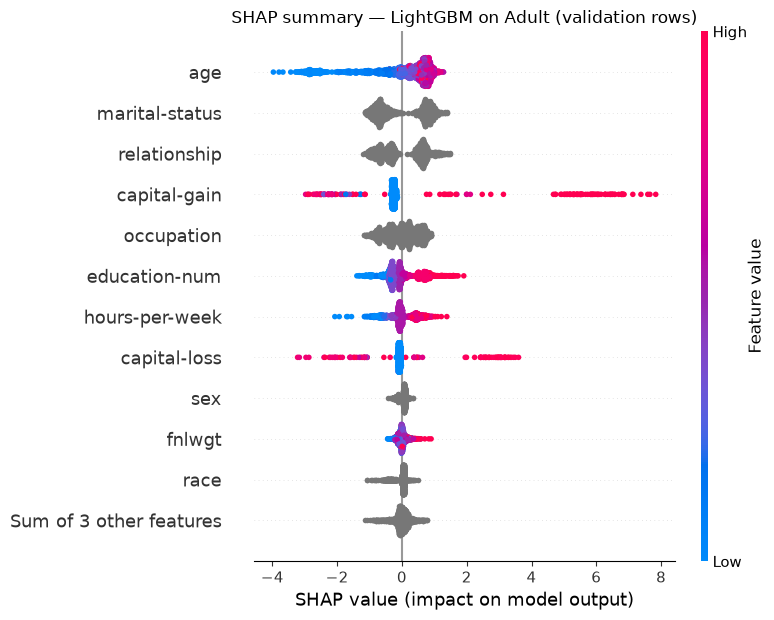

In [30]:
X_explain = X_val.iloc[:2000]
explainer = shap.TreeExplainer(lgb_sk)
explanation = explainer(X_explain)                              # shap.Explanation: values, base_values, data

raw_scores = lgb_sk.predict(X_explain, raw_score=True)          # log-odds
additive = np.allclose(explanation.base_values + explanation.values.sum(axis=1), raw_scores, atol=1e-4)
print("SHAP values shape:", explanation.values.shape, "| base + sum(SHAP) == raw log-odds:", additive)

shap.plots.beeswarm(explanation, max_display=12, show=False)
plt.title("SHAP summary — LightGBM on Adult (validation rows)")
plt.tight_layout()
plt.show()

In [31]:
compare = pd.DataFrame({
    "split count": lgb_sk.booster_.feature_importance("split"),
    "total gain": lgb_sk.booster_.feature_importance("gain"),
    "mean |SHAP|": np.abs(explanation.values).mean(axis=0),
}, index=X_tr.columns)
rank_table = compare.rank(ascending=False).astype(int).sort_values("mean |SHAP|")
print(rank_table)
biggest = (rank_table["split count"] - rank_table["mean |SHAP|"]).abs().idxmax()
print(f"\nBiggest disagreement: '{biggest}' is #{rank_table.loc[biggest, 'split count']} by split count "
      f"but #{rank_table.loc[biggest, 'mean |SHAP|']} by mean |SHAP|.")

                split count  total gain  mean |SHAP|
age                       1           5            1
marital-status           13           4            2
relationship             12           1            3
capital-gain              5           2            4
occupation                7           6            5
education-num             6           3            6
hours-per-week            3           8            7
capital-loss              4           7            8
sex                      11          12            9
fnlwgt                    2           9           10
race                     14          14           11
education                 9          13           12
workclass                 8          10           13
native-country           10          11           14

Biggest disagreement: 'marital-status' is #13 by split count but #2 by mean |SHAP|.


**How to read the beeswarm:** each dot is a row. Its x-position is the SHAP value (right = pushes towards >\$50K), and its colour is the feature value (red = high). Categorical features are shown in grey because they have no numeric "high/low".

### ✍️ Your Turn

Using only `explanation` (not the model), compute the model's **raw log-odds prediction for the first row** of `X_explain`.

In [32]:
raw_first_row = None  # TODO: base value + sum of that row's SHAP values
check("raw_first_row", raw_first_row, lgb_sk.predict(X_explain.iloc[[0]], raw_score=True)[0],
      hint="explanation.base_values[0] + explanation.values[0].sum()")

⏳ raw_first_row: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
raw_first_row = explanation.base_values[0] + explanation.values[0].sum()
check("raw_first_row", raw_first_row, lgb_sk.predict(X_explain.iloc[[0]], raw_score=True)[0])
```

SHAP for a classifier is in **log-odds** space here; apply the sigmoid to get the probability.
</details>

> 💡 **Interview angle:** "Why not trust `feature_importances_`?" — split counts favour high-cardinality/continuous features, gain can be inconsistent, both are computed on training data, and correlated features share credit unpredictably. SHAP gives consistent, additive, per-row attributions. But SHAP explains the **model**, not causality.

## 12. A Fair Head-to-Head Comparison 🟡

To compare libraries fairly:
- use the **same folds** for every model (fixed `StratifiedKFold` indices),
- give each a **comparable budget** (same number of trees and learning rate, similar tree size),
- measure **score and time**, and report the fold-to-fold spread, not just the mean.

We use 3-fold CV on the **training split only**, so validation and test remain untouched.

In [33]:
folds = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED).split(X_tr, y_tr))
X_tr_cb = fill_missing_categories(X_tr)

contenders = {
    "XGBoost": (lambda: xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                          enable_categorical=True, random_state=SEED), X_tr),
    "LightGBM": (lambda: lgb.LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31, verbose=-1,
                                            random_state=SEED), X_tr),
    "CatBoost": (lambda: CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, cat_features=cat_cols,
                                            random_seed=SEED, verbose=0, allow_writing_files=False), X_tr_cb),
    "HistGB": (lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, max_leaf_nodes=31,
                                                      early_stopping=False, random_state=SEED), X_tr),
}
cv_rows = []
for name, (make_model, X_data) in contenders.items():
    for fold, (fit_idx, score_idx) in enumerate(folds):
        start = time.perf_counter()
        model = make_model().fit(X_data.iloc[fit_idx], y_tr.iloc[fit_idx])
        seconds = time.perf_counter() - start
        proba = model.predict_proba(X_data.iloc[score_idx])[:, 1]
        cv_rows.append({"model": name, "fold": fold, "AUC": roc_auc_score(y_tr.iloc[score_idx], proba),
                        "log-loss": log_loss(y_tr.iloc[score_idx], proba), "fit seconds": seconds})

cv_results = pd.DataFrame(cv_rows)
summary = cv_results.groupby("model").agg(AUC_mean=("AUC", "mean"), AUC_std=("AUC", "std"),
                                          logloss_mean=("log-loss", "mean"), seconds=("fit seconds", "mean"))
print(summary.sort_values("AUC_mean", ascending=False).round(4))

top, runner_up = summary["AUC_mean"].nlargest(2).index
gap = summary.loc[top, "AUC_mean"] - summary.loc[runner_up, "AUC_mean"]
noise = summary["AUC_std"].max()
print(f"\n{top} leads {runner_up} by {gap:.4f} AUC; the largest fold std is {noise:.4f}.")
print("→ The gap is within fold-to-fold noise: treat them as tied at this budget." if gap < noise
      else "→ The gap is larger than fold-to-fold noise.")
print(f"Fastest: {summary['seconds'].idxmin()} ({summary['seconds'].min():.1f}s per fit) | "
      f"slowest: {summary['seconds'].idxmax()} ({summary['seconds'].max():.1f}s per fit)")

          AUC_mean  AUC_std  logloss_mean  seconds
model                                             
CatBoost    0.9270   0.0025        0.2802   4.9870
XGBoost     0.9243   0.0028        0.2873   1.2464
HistGB      0.9238   0.0027        0.2898  12.7598
LightGBM    0.9231   0.0024        0.2897   3.4627

CatBoost leads XGBoost by 0.0027 AUC; the largest fold std is 0.0028.
→ The gap is within fold-to-fold noise: treat them as tied at this budget.
Fastest: XGBoost (1.2s per fit) | slowest: HistGB (12.8s per fit)


On a clean dataset like this, the four libraries usually land within a few thousandths of AUC. The choice then comes down to speed, categorical handling, deployment and your team's familiarity, not a leaderboard decimal.

**About the timings:** every library here uses all CPU cores by default, so fit times depend heavily on your CPU and on whatever else is running (a busy laptop can make one library look several times slower on one run and not the next). Re-run the cell before drawing speed conclusions; for serious benchmarks, repeat runs and pin the thread count (`n_jobs` / `thread_count`) to the same value for every library.

> 💡 **Interview angle:** "Which is best: XGBoost, LightGBM or CatBoost?" — "It depends, so I'd measure": same folds, same budget, early stopping inside the training data, report mean ± std and time. Rules of thumb: CatBoost for many high-cardinality categoricals with little tuning, LightGBM for speed on large data, XGBoost for its ecosystem and robust defaults, HGB as a no-install baseline.

## 🔧 Build It From Scratch

### 1) Gradient boosting for regression, matching scikit-learn exactly

`GradientBoostingRegressor` with squared error does exactly the loop from Section 3: start at the mean, fit a `DecisionTreeRegressor` to the residuals, add `learning_rate × tree`. One subtle detail: scikit-learn trees randomly permute features even when using all of them, which only matters to **break ties** between equally good splits. `GradientBoostingRegressor` passes **one shared `RandomState`** to all its trees, so we do the same to reproduce it to floating-point precision.

In [34]:
class ScratchGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0):
        self.n_estimators, self.learning_rate = n_estimators, learning_rate
        self.max_depth, self.random_state = max_depth, random_state

    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        shared_rng = np.random.RandomState(self.random_state)   # same tie-breaking stream as sklearn
        self.init_ = y.mean()                                   # F0 = argmin of squared error = mean
        F = np.full(len(y), self.init_)
        self.trees_ = []
        for _ in range(self.n_estimators):
            residuals = y - F                                   # negative gradient of ½(y − F)²
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=shared_rng).fit(X, residuals)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
        return self

    def predict(self, X):
        return self.init_ + self.learning_rate * np.sum([tree.predict(X) for tree in self.trees_], axis=0)


start = time.perf_counter()
ours = ScratchGradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=SEED).fit(Xh_train, yh_train)
ours_seconds = time.perf_counter() - start
start = time.perf_counter()
theirs = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=SEED).fit(Xh_train, yh_train)
theirs_seconds = time.perf_counter() - start

diff = np.abs(ours.predict(Xh_test) - theirs.predict(Xh_test)).max()
assert diff < 1e-8, f"predictions differ by {diff}"
print(f"✅ scratch vs sklearn: max |difference| on the test set = {diff:.2e}")
print(f"test RMSE — scratch {root_mean_squared_error(yh_test, ours.predict(Xh_test)):.4f} | "
      f"sklearn {root_mean_squared_error(yh_test, theirs.predict(Xh_test)):.4f} "
      f"(fit {ours_seconds:.1f}s vs {theirs_seconds:.1f}s)")

✅ scratch vs sklearn: max |difference| on the test set = 6.22e-15
test RMSE — scratch 0.5422 | sklearn 0.5422 (fit 2.0s vs 2.0s)


### 2) XGBoost's leaf weights and split gain by hand

Tiny dataset, **one tree of depth 1** (a stump), `learning_rate=1`, `reg_lambda=λ`, and a fixed `base_score=0` so every starting prediction is 0. For squared error $g_i = \hat y_i - y_i = -y_i$ and $h_i = 1$. We try every threshold, compute the gain, pick the best, compute $w^* = -G/(H+\lambda)$ per side, and compare with the trained booster's dump. We use `tree_method="exact"` so XGBoost also places thresholds at midpoints between values.

In [35]:
X_hand = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0]])
y_hand = np.array([1.0, 1.5, 2.0, 6.0, 7.0, 7.5])
LAMBDA, BASE = 1.0, 0.0

g, h = grad_hess(y_hand, np.full_like(y_hand, BASE), "squared_error")


def score(G, H, lam=LAMBDA):
    return G ** 2 / (H + lam)


candidates = []
for threshold in (X_hand[:-1, 0] + X_hand[1:, 0]) / 2:           # midpoints 1.5, 2.5, ...
    left = X_hand[:, 0] < threshold
    gain = score(g[left].sum(), h[left].sum()) + score(g[~left].sum(), h[~left].sum()) - score(g.sum(), h.sum())
    candidates.append((threshold, gain))
    print(f"threshold {threshold}: gain (no ½) = {gain:8.4f} | textbook ½·gain = {gain / 2:8.4f}")

best_threshold, best_gain = max(candidates, key=lambda t: t[1])
left = X_hand[:, 0] < best_threshold
w_left = leaf_weight(g[left].sum(), h[left].sum(), LAMBDA)
w_right = leaf_weight(g[~left].sum(), h[~left].sum(), LAMBDA)
print(f"\nby hand → split x < {best_threshold}, gain {best_gain:.4f}, leaves [{w_left:.4f}, {w_right:.4f}]")

stump = xgb.XGBRegressor(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=LAMBDA, base_score=BASE,
                         tree_method="exact", objective="reg:squarederror").fit(X_hand, y_hand)
node = json.loads(stump.get_booster().get_dump(dump_format="json", with_stats=True)[0])
print("XGBoost →", stump.get_booster().get_dump(with_stats=True)[0].strip().replace("\n", " | "))

assert np.isclose(node["split_condition"], best_threshold)
assert np.isclose(node["gain"], best_gain, rtol=1e-6)
assert np.allclose([node["children"][0]["leaf"], node["children"][1]["leaf"]], [w_left, w_right], rtol=1e-6)
assert np.allclose(stump.predict(X_hand), np.where(left, w_left, w_right), rtol=1e-6)
print("✅ threshold, gain, leaf weights and predictions all match XGBoost", xgb.__version__)

threshold 1.5: gain (no ½) =   7.2143 | textbook ½·gain =   3.6071
threshold 2.5: gain (no ½) =  14.0476 | textbook ½·gain =   7.0238
threshold 3.5: gain (no ½) =  20.8393 | textbook ½·gain =  10.4196
threshold 4.5: gain (no ½) =   2.8476 | textbook ½·gain =   1.4238
threshold 5.5: gain (no ½) = -10.1190 | textbook ½·gain =  -5.0595

by hand → split x < 3.5, gain 20.8393, leaves [1.1250, 5.1250]
XGBoost → 0:[f0<3.5] yes=1,no=2,missing=1,gain=20.8392868,cover=6 | 	1:leaf=1.125,cover=3 | 	2:leaf=5.125,cover=3
✅ threshold, gain, leaf weights and predictions all match XGBoost 3.4.1


Now let's verify what `gamma`, `min_child_weight`, `learning_rate` and the log-loss hessian do, against the same booster.

In [36]:
def stump_dump(**params):
    base = dict(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=LAMBDA, base_score=BASE, tree_method="exact")
    model = xgb.XGBRegressor(**{**base, **params}).fit(X_hand, y_hand)
    return json.loads(model.get_booster().get_dump(dump_format="json", with_stats=True)[0])


# gamma: the split survives only if the (no-½) gain is at least gamma
kept = stump_dump(gamma=best_gain - 0.01)
pruned = stump_dump(gamma=best_gain + 0.01)
assert "children" in kept and "children" not in pruned
assert np.isclose(pruned["leaf"], -g.sum() / (h.sum() + LAMBDA), rtol=1e-6)          # single root leaf
print(f"✅ gamma={best_gain - 0.01:.2f} keeps the split, gamma={best_gain + 0.01:.2f} prunes it "
      f"→ root leaf {pruned['leaf']:.4f} = -G/(H+λ)")

# min_child_weight: each child needs a hessian sum ≥ min_child_weight (here H=3 per side)
assert "children" in stump_dump(min_child_weight=3) and "children" not in stump_dump(min_child_weight=3.5)
print("✅ min_child_weight=3 allows the split (H=3 per child), 3.5 blocks it")

# learning_rate: stored leaf values are already multiplied by eta
shrunk = stump_dump(learning_rate=0.3)
assert np.allclose([shrunk["children"][0]["leaf"], shrunk["children"][1]["leaf"]], [0.3 * w_left, 0.3 * w_right], rtol=1e-6)
print("✅ with learning_rate=0.3 the dumped leaves are 0.3 × w*")

# Log-loss: base_score=0.5 → p=0.5 for every row, so g = 0.5 − y and h = 0.25 (a real second-order case)
y_cls = np.array([0, 0, 0, 1, 1, 1])
g_c, h_c = grad_hess(y_cls, np.zeros(6), "log_loss")
clf_stump = xgb.XGBClassifier(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=LAMBDA, base_score=0.5,
                              min_child_weight=0, tree_method="exact").fit(X_hand, y_cls)
clf_node = json.loads(clf_stump.get_booster().get_dump(dump_format="json", with_stats=True)[0])
split_left = X_hand[:, 0] < clf_node["split_condition"]
expected_leaves = [leaf_weight(g_c[split_left].sum(), h_c[split_left].sum(), LAMBDA),
                   leaf_weight(g_c[~split_left].sum(), h_c[~split_left].sum(), LAMBDA)]
assert np.allclose([clf_node["children"][0]["leaf"], clf_node["children"][1]["leaf"]], expected_leaves, rtol=1e-5)
assert np.allclose(clf_stump.predict(X_hand, output_margin=True), np.where(split_left, *expected_leaves), rtol=1e-5)
print(f"✅ log-loss leaves {np.round(expected_leaves, 4)} = -G/(H+λ) with h = p(1−p) = 0.25 per row")

✅ gamma=20.83 keeps the split, gamma=20.85 prunes it → root leaf 3.5714 = -G/(H+λ)
✅ min_child_weight=3 allows the split (H=3 per child), 3.5 blocks it
✅ with learning_rate=0.3 the dumped leaves are 0.3 × w*
✅ log-loss leaves [-0.8571  0.8571] = -G/(H+λ) with h = p(1−p) = 0.25 per row


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Early stopping (or tuning) on the test set

If you pick the number of trees and the configuration by looking at the test score, that score is no longer an honest estimate. To *show* the bias we use small California splits (so selection noise is visible): 2,000 training rows, 400 validation rows, 400 test rows, and a large **"fresh"** set standing in for future production data. **Optimism** = fresh RMSE − reported test RMSE. One split is noisy, so we repeat the experiment on 8 different random splits and average.

In [37]:
depths = [2, 3, 4, 6, 8]


def pick_on(X_fit, y_fit, X_select, y_select):
    """Try several depths, early-stop each on (X_select, y_select), return the best model."""
    best_model, best_rmse = None, np.inf
    for depth in depths:
        model = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.1, max_depth=depth, early_stopping_rounds=30,
                                 random_state=SEED)
        model.fit(X_fit, y_fit, eval_set=[(X_select, y_select)], verbose=False)
        rmse = root_mean_squared_error(y_select, model.predict(X_select))
        if rmse < best_rmse:
            best_model, best_rmse = model, rmse
    return best_model


optimism_rows = []
for repeat in range(8):
    X_rest, X_fresh, y_rest, y_fresh = train_test_split(X_house, y_house, test_size=0.4, random_state=repeat)
    X_s_tr, X_s_rest, y_s_tr, y_s_rest = train_test_split(X_rest, y_rest, train_size=2000, random_state=repeat)
    X_s_val, X_s_test, y_s_val, y_s_test = train_test_split(X_s_rest, y_s_rest, train_size=400, test_size=400,
                                                            random_state=repeat)
    for label, (X_sel, y_sel) in [("❌ picked on TEST", (X_s_test, y_s_test)), ("✅ picked on VALIDATION", (X_s_val, y_s_val))]:
        model = pick_on(X_s_tr, y_s_tr, X_sel, y_sel)
        reported = root_mean_squared_error(y_s_test, model.predict(X_s_test))
        fresh = root_mean_squared_error(y_fresh, model.predict(X_fresh))
        optimism_rows.append({"approach": label, "repeat": repeat, "reported test RMSE": reported,
                              "fresh RMSE": fresh, "optimism": fresh - reported})

optimism = pd.DataFrame(optimism_rows).groupby("approach")[["reported test RMSE", "fresh RMSE", "optimism"]].mean()
print("average over 8 random splits:")
print(optimism.round(4))
extra = optimism.loc["❌ picked on TEST", "optimism"] - optimism.loc["✅ picked on VALIDATION", "optimism"]
print(f"\n→ Selecting on the test set made the reported RMSE look {extra:.4f} better than reality, on top of what the honest workflow shows."
      if extra > 0 else "\n→ No extra optimism appeared in these repeats; the bias is real but can be small with few choices.")

average over 8 random splits:
                        reported test RMSE  fresh RMSE  optimism
approach                                                        
✅ picked on VALIDATION              0.5334      0.5440    0.0106
❌ picked on TEST                    0.5181      0.5415    0.0234

→ Selecting on the test set made the reported RMSE look 0.0127 better than reality, on top of what the honest workflow shows.


When the test set is used to choose the depth and the number of trees, the reported test RMSE is too good compared with fresh data: the test set helped choose, so it no longer measures generalization. The honest workflow's reported score is much closer to what fresh data shows. The more choices you make on a set (more configs, more thresholds, more features), the bigger this bias.

### ❌ Pitfall 2 — `subsample` without `subsample_freq` in LightGBM

In [38]:
X_num_tr = X_tr[num_cols]
reference = lgb.LGBMClassifier(n_estimators=50, verbose=-1, random_state=SEED).fit(X_num_tr, y_tr).predict_proba(X_num_tr)
wrong = lgb.LGBMClassifier(n_estimators=50, subsample=0.5, verbose=-1, random_state=SEED).fit(X_num_tr, y_tr).predict_proba(X_num_tr)
right = lgb.LGBMClassifier(n_estimators=50, subsample=0.5, subsample_freq=1, verbose=-1,
                           random_state=SEED).fit(X_num_tr, y_tr).predict_proba(X_num_tr)
print("❌ subsample=0.5 alone — identical to no bagging:", np.array_equal(wrong, reference))
print("✅ + subsample_freq=1  — identical to no bagging:", np.array_equal(right, reference))

❌ subsample=0.5 alone — identical to no bagging: True
✅ + subsample_freq=1  — identical to no bagging: False


### ❌ Pitfall 3 — NaN inside a CatBoost categorical column

In [39]:
try:
    CatBoostClassifier(iterations=10, verbose=0, allow_writing_files=False).fit(X_tr, y_tr, cat_features=cat_cols)
except cb.CatBoostError as err:
    print("❌", str(err).splitlines()[0][:160])

fixed = CatBoostClassifier(iterations=10, verbose=0, allow_writing_files=False, random_seed=SEED)
fixed.fit(fill_missing_categories(X_tr), y_tr, cat_features=cat_cols)
print("✅ after mapping NaN → 'missing': trained", fixed.tree_count_, "trees")

❌ Invalid type for cat_feature[object_idx=24,feature_idx=1]=NaN : cat_features must be integer or string, real number values and NaN values should be converted to
✅ after mapping NaN → 'missing': trained 10 trees


### ❌ Pitfall 4 — Naive target encoding leaks the label into a feature

We give LightGBM the numeric features plus the **naively target-encoded noise ID** from Section 9, and compare with CatBoost receiving the raw ID as a categorical feature.

In [40]:
X_num_val = X_val[num_cols]
without_id = lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED).fit(X_num_tr, y_tr)
auc_without = roc_auc_score(y_val, without_id.predict_proba(X_num_val)[:, 1])

leaky = lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED).fit(X_num_tr.assign(id_te=naive_train), y_tr)
auc_leaky_train = roc_auc_score(y_tr, leaky.predict_proba(X_num_tr.assign(id_te=naive_train))[:, 1])
auc_leaky = roc_auc_score(y_val, leaky.predict_proba(X_num_val.assign(id_te=naive_val))[:, 1])
gain_share = leaky.booster_.feature_importance("gain")[-1] / leaky.booster_.feature_importance("gain").sum()

cat_id = CatBoostClassifier(iterations=200, verbose=0, allow_writing_files=False, random_seed=SEED)
cat_id.fit(X_num_tr.assign(customer_id=id_train), y_tr, cat_features=["customer_id"])
auc_cat = roc_auc_score(y_val, cat_id.predict_proba(X_num_val.assign(customer_id=id_val))[:, 1])

print(f"numeric features only (LightGBM)          : val AUC {auc_without:.4f}")
print(f"❌ + naive target-encoded ID (LightGBM)    : train AUC {auc_leaky_train:.4f} | val AUC {auc_leaky:.4f} "
      f"| the noise ID gets {gain_share:.0%} of total gain")
print(f"✅ + raw ID as cat_feature (CatBoost, ordered TS): val AUC {auc_cat:.4f}")

numeric features only (LightGBM)          : val AUC 0.8746
❌ + naive target-encoded ID (LightGBM)    : train AUC 0.9521 | val AUC 0.7248 | the noise ID gets 30% of total gain
✅ + raw ID as cat_feature (CatBoost, ordered TS): val AUC 0.8742


The leaky feature looks like the most useful column during training, and validation AUC drops sharply. Fixes: CatBoost's ordered statistics, or out-of-fold target encoding (e.g. scikit-learn's `TargetEncoder`, which cross-fits inside `fit_transform`).

### ❌ Pitfall 5 — Trusting split-count importance

Add a column of **pure random noise** and see how each importance ranks it.

In [41]:
X_noise_tr = X_tr.assign(random_noise=rng.normal(size=len(X_tr)))
X_noise_val = X_val.assign(random_noise=rng.normal(size=len(X_val)))
noisy_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=SEED).fit(X_noise_tr, y_tr)
noise_shap = shap.TreeExplainer(noisy_model)(X_noise_val.iloc[:2000])

noise_ranks = pd.DataFrame({
    "split count": noisy_model.booster_.feature_importance("split"),
    "total gain": noisy_model.booster_.feature_importance("gain"),
    "mean |SHAP| (validation)": np.abs(noise_shap.values).mean(axis=0),
}, index=X_noise_tr.columns).rank(ascending=False).astype(int)
print(f"rank of 'random_noise' among {len(X_noise_tr.columns)} features:")
print(noise_ranks.loc["random_noise"].to_string())

rank of 'random_noise' among 15 features:
split count                  2
total gain                  10
mean |SHAP| (validation)    13


A column of pure noise ranks surprisingly high by **split count**, because a continuous feature offers thousands of thresholds to overfit on. It drops under gain and SHAP. Prefer SHAP (or permutation importance on validation data) when you present "what drives the model".

### ❌ Pitfall 6 — Outdated APIs: `evals_result=` in `lgb.train`

In [42]:
try:
    lgb.train({"objective": "binary", "verbose": -1}, lgb.Dataset(X_num_tr, label=y_tr), num_boost_round=5,
              valid_sets=[lgb.Dataset(X_num_val, label=y_val)], evals_result={})
except TypeError as err:
    print("❌", err)

history = {}
lgb.train({"objective": "binary", "verbose": -1}, lgb.Dataset(X_num_tr, label=y_tr), num_boost_round=5,
          valid_sets=[lgb.Dataset(X_num_val, label=y_val)], callbacks=[lgb.record_evaluation(history)])
print("✅ callbacks=[lgb.record_evaluation(history)] →", {k: list(v) for k, v in history.items()})

❌ train() got an unexpected keyword argument 'evals_result'
✅ callbacks=[lgb.record_evaluation(history)] → {'valid_0': ['binary_logloss']}


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Split gain function
Write `xgb_gain(GL, HL, GR, HR, lam, gamma)` using XGBoost's **implementation** form (no ½): left score + right score − parent score − γ.

In [43]:
def xgb_gain(GL, HL, GR, HR, lam, gamma=0.0):
    return None  # TODO


check("xgb_gain", xgb_gain(-6, 2, 6, 2, lam=1, gamma=4), 20.0,
      hint="G²/(H+λ) for left and right, minus (GL+GR)²/(HL+HR+λ), minus gamma.")

⏳ xgb_gain: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def xgb_gain(GL, HL, GR, HR, lam, gamma=0.0):
    return GL**2 / (HL + lam) + GR**2 / (HR + lam) - (GL + GR)**2 / (HL + HR + lam) - gamma


check("xgb_gain", xgb_gain(-6, 2, 6, 2, lam=1, gamma=4), 20.0)
```

36/3 + 36/3 − 0/5 − 4 = 20. The parent's gradients cancel (G = 0), so the parent alone can't improve the loss, but the split separates the rows pushing up from the rows pushing down.
</details>

### 🟢 Exercise 2 — What value does the dumped leaf store?
A leaf has `G = -9`, `H = 2`, with `reg_lambda = 1` and `learning_rate = 0.1`. What number does `get_dump()` show for this leaf?

In [44]:
dumped_leaf = None  # TODO
check("dumped_leaf", dumped_leaf, 0.3, hint="XGBoost stores eta × (−G/(H+λ)).")

⏳ dumped_leaf: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dumped_leaf = 0.1 * leaf_weight(-9, 2, 1)
check("dumped_leaf", dumped_leaf, 0.3)
```

−(−9)/(2+1) = 3, times η = 0.1 → 0.3 (verified against a real booster in 🔧 Build It From Scratch).
</details>

### 🟢 Exercise 3 — A strong baseline in three lines
Fit `HistGradientBoostingRegressor(random_state=SEED)` on `Xh_train, yh_train` and store its **test R²** in `hgb_r2`. The checker requires R² > 0.80, clearly better than the best single tree in Section 1.

In [45]:
hgb_r2 = None  # TODO
check("hgb_r2_above_0.80", None if hgb_r2 is None else bool(hgb_r2 > 0.80), True,
      hint="HistGradientBoostingRegressor(random_state=SEED).fit(...), then r2_score(yh_test, model.predict(Xh_test)).")

⏳ hgb_r2_above_0.80: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
hgb_reg = HistGradientBoostingRegressor(random_state=SEED).fit(Xh_train, yh_train)
hgb_r2 = r2_score(yh_test, hgb_reg.predict(Xh_test))
print(f"HistGradientBoostingRegressor test R² = {hgb_r2:.3f}")
check("hgb_r2_above_0.80", bool(hgb_r2 > 0.80), True)
```
</details>

### 🟡 Exercise 4 — Monotonic LightGBM
Train an `LGBMRegressor(n_estimators=300, verbose=-1, random_state=SEED)` on `Xh_tr, yh_tr` whose predictions can **never decrease as `MedInc` increases**. Store it in `mono_lgb`. The checker sweeps `MedInc` over the `grid` from Section 7c.

In [46]:
mono_lgb = None  # TODO

is_monotone = None
if mono_lgb is not None:
    sweep = mono_lgb.predict(grid)
    is_monotone = bool(np.all(np.diff(sweep) >= -1e-9)) and mono_lgb.get_params().get("monotone_constraints") is not None
check("monotone_medinc", is_monotone, True,
      hint="monotone_constraints takes one entry per column: 1 for MedInc, 0 elsewhere (in Xh_tr.columns order).")

⏳ monotone_medinc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
constraints = [1 if col == "MedInc" else 0 for col in Xh_tr.columns]
mono_lgb = lgb.LGBMRegressor(n_estimators=300, monotone_constraints=constraints, verbose=-1,
                             random_state=SEED).fit(Xh_tr, yh_tr)

sweep = mono_lgb.predict(grid)
is_monotone = bool(np.all(np.diff(sweep) >= -1e-9)) and mono_lgb.get_params().get("monotone_constraints") is not None
check("monotone_medinc", is_monotone, True)
```
</details>

### 🟡 Exercise 5 — Rebuild `total_gain`
XGBoost's `gain` importance is the **average** gain per split, and `weight` is the number of splits. Rebuild `total_gain` for every feature of `xgb_adult` from those two, as a dict `{feature: value}`.

In [47]:
adult_booster = xgb_adult.get_booster()
weight_scores = adult_booster.get_score(importance_type="weight")
gain_scores = adult_booster.get_score(importance_type="gain")
total_gain = None  # TODO: dict feature -> total gain
check("total_gain", total_gain, adult_booster.get_score(importance_type="total_gain"),
      hint="{f: gain_scores[f] * weight_scores[f] for f in gain_scores}")

⏳ total_gain: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
adult_booster = xgb_adult.get_booster()
weight_scores = adult_booster.get_score(importance_type="weight")
gain_scores = adult_booster.get_score(importance_type="gain")
total_gain = {feature: gain_scores[feature] * weight_scores[feature] for feature in gain_scores}
check("total_gain", total_gain, adult_booster.get_score(importance_type="total_gain"))
```

This is why `gain` alone can mislead: a feature used once for a single lucky split can have a higher *average* gain than a feature used 500 times.
</details>

### 🔴 Exercise 6 — Binary gradient boosting with Newton leaves (interview classic)

Implement boosting for **binary log-loss** from scratch and match `GradientBoostingClassifier` on the real breast-cancer dataset:
1. Start from the log-odds of the positive rate: $F_0 = \log\frac{\bar y}{1-\bar y}$.
2. Each round: $p = \sigma(F)$, fit a `DecisionTreeRegressor(max_depth=depth, random_state=shared_rng)` to the negative gradient $y - p$.
3. **Replace each leaf's value** with the Newton step $\sum (y-p) / \sum p(1-p)$ over the training rows in that leaf (use `tree.apply(X)` to get leaf ids).
4. $F \leftarrow F + \eta \cdot \text{leaf value}$. Return $\sigma(F)$ for `X_new`.

The checker compares probabilities on the **training rows**. Why not the test rows? This dataset has near-duplicate features (e.g. `radius error` and `perimeter error`) that sometimes split the training rows *identically*. Which one wins that tie comes down to ~1e-16 rounding, and the two features can route unseen test rows differently. Training predictions are identical either way; the solution also prints how often the test-set labels agree.

In [48]:
Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, stratify=yb, random_state=SEED)


def newton_boost_predict_proba(X, y, X_new, n_trees=50, lr=0.1, depth=2, seed=SEED):
    # TODO: implement steps 1-4 and return probabilities for X_new
    return None


sk_gbc = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=2, random_state=SEED).fit(Xb_tr, yb_tr)
check("newton_boost", newton_boost_predict_proba(Xb_tr, yb_tr, Xb_tr), sk_gbc.predict_proba(Xb_tr)[:, 1],
      hint="Share ONE np.random.RandomState(seed) across all trees; leaf value = sum(residual) / sum(p*(1-p)) per leaf.")

⏳ newton_boost: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, stratify=yb, random_state=SEED)


def newton_boost_predict_proba(X, y, X_new, n_trees=50, lr=0.1, depth=2, seed=SEED):
    shared_rng = np.random.RandomState(seed)
    F0 = np.log(y.mean() / (1 - y.mean()))
    F, F_new = np.full(len(X), F0), np.full(len(X_new), F0)
    for _ in range(n_trees):
        p = 1 / (1 + np.exp(-F))
        residual = y - p                                       # negative gradient
        tree = DecisionTreeRegressor(max_depth=depth, random_state=shared_rng).fit(X, residual)
        leaf_train, leaf_new = tree.apply(X), tree.apply(X_new)
        values = {}
        for leaf in np.unique(leaf_train):
            in_leaf = leaf_train == leaf
            hessian = (p[in_leaf] * (1 - p[in_leaf])).sum()
            values[leaf] = residual[in_leaf].sum() / hessian if hessian > 1e-150 else 0.0   # Newton step
        F += lr * np.array([values[leaf] for leaf in leaf_train])
        F_new += lr * np.array([values[leaf] for leaf in leaf_new])
    return 1 / (1 + np.exp(-F_new))


sk_gbc = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=2, random_state=SEED).fit(Xb_tr, yb_tr)
check("newton_boost", newton_boost_predict_proba(Xb_tr, yb_tr, Xb_tr), sk_gbc.predict_proba(Xb_tr)[:, 1])

ours_test = newton_boost_predict_proba(Xb_tr, yb_tr, Xb_te)
print(f"test labels agree with sklearn on {((ours_test > 0.5) == (sk_gbc.predict_proba(Xb_te)[:, 1] > 0.5)).mean():.1%} of rows | "
      f"test accuracy: ours {((ours_test > 0.5) == yb_te).mean():.3f} vs sklearn {sk_gbc.score(Xb_te, yb_te):.3f}")
```

The tree picks the **split structure** using the gradient (a squared-error fit), but the **leaf values** use the gradient/hessian ratio. That is the same Newton idea XGBoost builds into its split gain, and it's a great answer to "why second order?".
</details>

## 🚀 Mini Project: Adult Income Prediction With Four Boosters

**Goal:** predict whether income is >\$50K with XGBoost, LightGBM, CatBoost and HistGradientBoosting. Tune each lightly on **validation**, early-stop on **validation**, pick one winner and a decision threshold on **validation**, then evaluate **once** on the untouched test set and explain the winner with SHAP.

**Steps:** check the splits → baseline → tuning sweep with early stopping → pick winner and threshold → single test evaluation → SHAP → conclusions.

### Step 1 — Check the splits (no overlap, same class balance)

In [49]:
assert not (set(X_tr.index) & set(X_val.index)) and not (set(X_tr.index) & set(X_test.index)) \
    and not (set(X_val.index) & set(X_test.index)), "splits overlap!"
split_summary = pd.DataFrame({"rows": [len(y_tr), len(y_val), len(y_test)],
                              "positive rate": [y_tr.mean(), y_val.mean(), y_test.mean()]},
                             index=["train", "validation", "test"])
print(split_summary.round(4))

             rows  positive rate
train       29305         0.2393
validation   9768         0.2393
test         9769         0.2393


### Step 2 — Baseline to beat

Always predicting the majority class ("≤50K") gives the accuracy floor; a constant probability gives ROC-AUC = 0.5.

In [50]:
majority_accuracy = accuracy_score(y_val, np.zeros_like(y_val))
constant_logloss = log_loss(y_val, np.full(len(y_val), y_tr.mean()))
print(f"majority-class accuracy on validation: {majority_accuracy:.4f} | constant-probability log-loss: {constant_logloss:.4f}")

majority-class accuracy on validation: 0.7607 | constant-probability log-loss: 0.5502


### Step 3 — Small tuning sweep with early stopping on validation

One tree-size knob per library, learning rate 0.05, up to 3,000 trees, patience 50. HistGradientBoosting cannot take an external validation set, so it early-stops on 10% of the training data and we score it on validation like the rest.

In [51]:
X_val_cb = fill_missing_categories(X_val)


def fit_candidate(library, size):
    if library == "XGBoost":
        model = xgb.XGBClassifier(n_estimators=3000, learning_rate=0.05, max_depth=size, enable_categorical=True,
                                  eval_metric="logloss", early_stopping_rounds=50, random_state=SEED)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        return model, model.best_iteration + 1, model.predict_proba(X_val)[:, 1]
    if library == "LightGBM":
        model = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, num_leaves=size, verbose=-1, random_state=SEED)
        model.fit(X_tr, y_tr, eval_X=X_val, eval_y=y_val, callbacks=[lgb.early_stopping(50, verbose=False)])
        return model, model.best_iteration_, model.predict_proba(X_val)[:, 1]
    if library == "CatBoost":
        model = CatBoostClassifier(iterations=3000, learning_rate=0.05, depth=size, random_seed=SEED, verbose=0,
                                   allow_writing_files=False)
        model.fit(X_tr_cb, y_tr, cat_features=cat_cols, eval_set=(X_val_cb, y_val), early_stopping_rounds=50)
        return model, model.tree_count_, model.predict_proba(X_val_cb)[:, 1]
    model = HistGradientBoostingClassifier(max_iter=3000, learning_rate=0.05, max_leaf_nodes=size, early_stopping=True,
                                           n_iter_no_change=50, random_state=SEED)
    model.fit(X_tr, y_tr)
    return model, model.n_iter_, model.predict_proba(X_val)[:, 1]


search_space = {"XGBoost": [4, 6, 8], "LightGBM": [15, 31, 63], "CatBoost": [4, 6, 8], "HistGB": [15, 31, 63]}
size_name = {"XGBoost": "max_depth", "LightGBM": "num_leaves", "CatBoost": "depth", "HistGB": "max_leaf_nodes"}
sweep_rows, fitted = [], {}
for library, sizes in search_space.items():
    for size in sizes:
        start = time.perf_counter()
        model, n_trees, val_proba = fit_candidate(library, size)
        seconds = time.perf_counter() - start
        fitted[(library, size)] = (model, val_proba)
        sweep_rows.append({"library": library, "setting": f"{size_name[library]}={size}", "size": size,
                           "trees": n_trees, "val log-loss": log_loss(y_val, val_proba),
                           "val AUC": roc_auc_score(y_val, val_proba), "seconds": seconds})

sweep = pd.DataFrame(sweep_rows)
print(sweep.drop(columns="size").sort_values("val log-loss").round(4).to_string(index=False))

 library           setting  trees  val log-loss  val AUC  seconds
CatBoost           depth=4   1169        0.2732   0.9306   9.1512
CatBoost           depth=6    490        0.2740   0.9303   5.9712
 XGBoost       max_depth=4    658        0.2742   0.9295   2.0465
LightGBM     num_leaves=31    248        0.2742   0.9297   3.6998
 XGBoost       max_depth=6    213        0.2742   0.9298   1.0373
LightGBM     num_leaves=15    365        0.2743   0.9299   2.5408
CatBoost           depth=8    403        0.2744   0.9301   6.7203
LightGBM     num_leaves=63    170        0.2748   0.9293   5.6078
 XGBoost       max_depth=8    187        0.2748   0.9291   1.2281
  HistGB max_leaf_nodes=31    321        0.2760   0.9285   7.7434
  HistGB max_leaf_nodes=15    327        0.2763   0.9286   3.1423
  HistGB max_leaf_nodes=63    213        0.2778   0.9277  12.3344


### Step 4 — Pick the winner and a decision threshold (validation only)

We rank by **validation log-loss** (it rewards well-calibrated probabilities; AUC is reported alongside). The threshold that maximizes F1 on validation becomes our decision rule.

                    setting  trees  val log-loss  val AUC  seconds
library                                                           
CatBoost            depth=4   1169        0.2732   0.9306   9.1512
XGBoost         max_depth=4    658        0.2742   0.9295   2.0465
LightGBM      num_leaves=31    248        0.2742   0.9297   3.6998
HistGB    max_leaf_nodes=31    321        0.2760   0.9285   7.7434



🏆 winner: CatBoost (depth=4, 1169 trees) | val log-loss 0.2732 | val AUC 0.9306
threshold chosen on validation: 0.44 (val F1 0.7337 vs 0.7185 at 0.5)


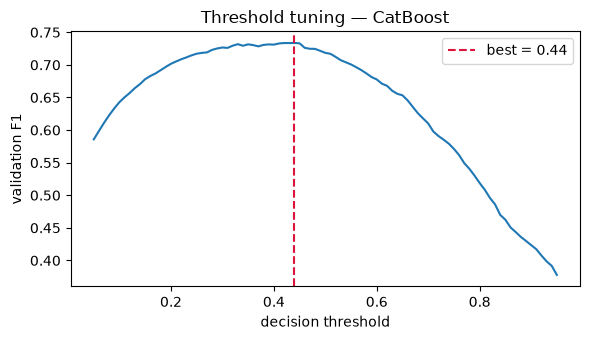

In [52]:
best_per_library = sweep.loc[sweep.groupby("library")["val log-loss"].idxmin()].set_index("library")
print(best_per_library[["setting", "trees", "val log-loss", "val AUC", "seconds"]].sort_values("val log-loss").round(4))

winner_row = sweep.loc[sweep["val log-loss"].idxmin()]
winner_library, winner_size = winner_row["library"], int(winner_row["size"])
winner_model, winner_val_proba = fitted[(winner_library, winner_size)]

thresholds = np.linspace(0.05, 0.95, 91)
val_f1 = [f1_score(y_val, (winner_val_proba >= t).astype(int)) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(val_f1))])
print(f"\n🏆 winner: {winner_library} ({winner_row['setting']}, {winner_row['trees']} trees) | "
      f"val log-loss {winner_row['val log-loss']:.4f} | val AUC {winner_row['val AUC']:.4f}")
print(f"threshold chosen on validation: {best_threshold:.2f} (val F1 {max(val_f1):.4f} vs {f1_score(y_val, (winner_val_proba >= 0.5).astype(int)):.4f} at 0.5)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thresholds, val_f1)
ax.axvline(best_threshold, ls="--", color="crimson", label=f"best = {best_threshold:.2f}")
ax.set(xlabel="decision threshold", ylabel="validation F1", title=f"Threshold tuning — {winner_library}")
ax.legend()
plt.tight_layout()
plt.show()

### Step 5 — The one and only test evaluation

In [53]:
X_test_for_winner = fill_missing_categories(X_test) if winner_library == "CatBoost" else X_test
test_proba = winner_model.predict_proba(X_test_for_winner)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_proba),
    "log-loss": log_loss(y_test, test_proba),
    f"accuracy @ {best_threshold:.2f}": accuracy_score(y_test, test_pred),
    f"F1 @ {best_threshold:.2f}": f1_score(y_test, test_pred),
    f"precision @ {best_threshold:.2f}": precision_score(y_test, test_pred),
    f"recall @ {best_threshold:.2f}": recall_score(y_test, test_pred),
    "majority-class accuracy": accuracy_score(y_test, np.zeros_like(y_test)),
}
for name, value in test_metrics.items():
    print(f"{name:28s} {value:.4f}")

ROC-AUC                      0.9299
log-loss                     0.2738
accuracy @ 0.44              0.8745
F1 @ 0.44                    0.7273
precision @ 0.44             0.7576
recall @ 0.44                0.6993
majority-class accuracy      0.7607


### Step 6 — Explain the winner with SHAP

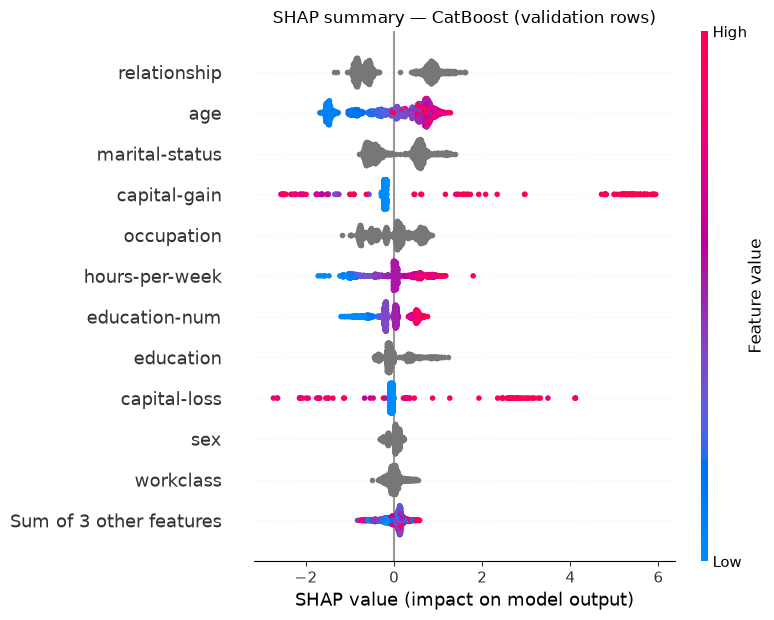

top 5 features by mean |SHAP|:
relationship      0.7824
age               0.7263
marital-status    0.5442
capital-gain      0.4640
occupation        0.4035


In [54]:
if winner_library == "HistGB":
    # shap's TreeExplainer does not parse HistGradientBoosting models with native categorical splits
    runner_up_library = best_per_library.drop(index="HistGB")["val log-loss"].idxmin()
    runner_up_size = int(best_per_library.loc[runner_up_library, "size"])
    print(f"ℹ️ TreeExplainer can't read HistGB's categorical splits; explaining the best other library ({runner_up_library}) instead.")
    explain_library, explain_model = runner_up_library, fitted[(runner_up_library, runner_up_size)][0]
else:
    explain_library, explain_model = winner_library, winner_model

X_shap = (X_val_cb if explain_library == "CatBoost" else X_val).iloc[:2000]
winner_explanation = shap.TreeExplainer(explain_model)(X_shap)
shap.plots.beeswarm(winner_explanation, max_display=12, show=False)
plt.title(f"SHAP summary — {explain_library} (validation rows)")
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(winner_explanation.values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
print("top 5 features by mean |SHAP|:")
print(mean_abs_shap.head(5).round(4).to_string())

### Step 7 — Conclusions (computed)

In [55]:
spread = best_per_library["val log-loss"].max() - best_per_library["val log-loss"].min()
auc_gap = abs(test_metrics["ROC-AUC"] - winner_row["val AUC"])
fastest = best_per_library["seconds"].idxmin()
print(f"1. Best validation log-loss: {winner_library} ({winner_row['setting']}). The four tuned libraries are within "
      f"{spread:.4f} log-loss of each other → {'practically tied' if spread < 0.01 else 'a meaningful spread'}.")
print(f"2. Test ROC-AUC {test_metrics['ROC-AUC']:.4f} vs validation {winner_row['val AUC']:.4f} (gap {auc_gap:.4f}) → "
      f"{'validation was a reliable guide' if auc_gap < 0.01 else 'check for distribution shift or overfitting to validation'}.")
print(f"3. Accuracy {test_metrics[f'accuracy @ {best_threshold:.2f}']:.4f} vs majority baseline "
      f"{test_metrics['majority-class accuracy']:.4f}; F1 {test_metrics[f'F1 @ {best_threshold:.2f}']:.4f} at the validation-tuned threshold {best_threshold:.2f}.")
print(f"4. Most influential features (SHAP, {explain_library}): {', '.join(mean_abs_shap.index[:3])}.")
print(f"5. Fastest tuned model to train: {fastest} ({best_per_library.loc[fastest, 'seconds']:.1f}s).")

1. Best validation log-loss: CatBoost (depth=4). The four tuned libraries are within 0.0028 log-loss of each other → practically tied.
2. Test ROC-AUC 0.9299 vs validation 0.9306 (gap 0.0007) → validation was a reliable guide.
3. Accuracy 0.8745 vs majority baseline 0.7607; F1 0.7273 at the validation-tuned threshold 0.44.
4. Most influential features (SHAP, CatBoost): relationship, age, marital-status.
5. Fastest tuned model to train: XGBoost (2.0s).


**Stretch goals**
1. Replace the 3-point sweep with **Optuna** (tune `learning_rate`, tree size, `min_child_samples`, `subsample` + `subsample_freq`, `reg_lambda`) using validation log-loss, and see whether the winner changes.
2. **Retrain the winner on train + validation** with its best number of trees (× ~1.25 for the extra data), then compare the test score. (Only do this *after* you have frozen every decision.)
3. Plot a **calibration curve** (`sklearn.calibration.CalibrationDisplay`) for the winner and for a `scale_pos_weight` version.
4. Report **PR-AUC** (`average_precision_score`) — more informative than ROC-AUC when positives are rare.
5. Try CatBoost with `boosting_type="Ordered"` and compare time and validation log-loss.

### 🗣️ How to talk about this in an interview
- "I used a stratified **train/validation/test** split. Early stopping, the tuning sweep, model selection and the decision threshold all used validation; the test set was scored exactly once."
- "All four boosters took the raw pandas categories and missing values natively — no one-hot encoding. CatBoost needed NaN in categorical columns mapped to an explicit 'missing' string."
- "I ranked by validation **log-loss** because the business may use the probabilities, reported ROC-AUC alongside, and tuned the F1 threshold on validation instead of using class weights, which would distort calibration."
- "The tuned libraries ended up very close, so I'd choose on latency, dependency footprint and team familiarity, not a third decimal."
- "SHAP showed which features drive the predictions; I sanity-checked that the ranking made domain sense and noted that split-count importance ranked even a random-noise column highly."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between bagging and boosting?**

<details><summary>Show answer</summary>

- **30-second answer:** Bagging trains many models **independently in parallel** on bootstrap samples and averages them, which reduces **variance** (Random Forest uses deep trees). Boosting trains weak models **sequentially**, each fitting the errors of the ensemble so far, which reduces **bias** (shallow trees, learning rate).
- **Go deeper:** Random forests don't overfit as you add trees; boosting does, so it needs early stopping. Bagging parallelizes across trees; boosting parallelizes only *inside* each tree (histogram building). Boosting is more sensitive to label noise and hyperparameters, and usually a bit more accurate when tuned.
- **❌ Common wrong answer:** "Boosting is just bagging with weighted samples" or "both reduce variance".

</details>

**Q2. Walk me through how gradient boosting works.**

<details><summary>Show answer</summary>

- **30-second answer:** Start with a constant prediction (the mean, or the log-odds for classification). At each round compute the negative gradient of the loss at the current predictions (the residuals, for squared error), fit a small regression tree to it, and add the tree's output times a learning rate. Repeat until validation loss stops improving.
- **Go deeper:** It is gradient descent in *function space* (Friedman, 2001). Leaf values can be re-optimized per leaf: mean residual for squared error, or a Newton step $\sum g / \sum h$ for log-loss (what sklearn's `GradientBoostingClassifier` does and what XGBoost builds into its gain). Different losses (Huber, quantile, Poisson, ranking) only change $g$ and $h$.
- **❌ Common wrong answer:** "Each tree is trained on the samples the previous tree misclassified" — that is **AdaBoost**'s re-weighting, not gradient boosting.

</details>

**Q3. Why does XGBoost use second-order (hessian) information?**

<details><summary>Show answer</summary>

- **30-second answer:** A second-order Taylor expansion turns each leaf's objective into a quadratic, so the optimal leaf value has a closed form $-G/(H+\lambda)$ and split gain can be scored exactly for **any** twice-differentiable loss, using just per-row $g$ and $h$. It is a Newton step: curvature sets the step size.
- **Go deeper:** For log-loss $h = p(1-p)$, so confident rows have little influence on the splits and leaf values adapt to curvature. This usually converges in fewer trees than first-order boosting. Custom objectives in XGBoost/LightGBM only need to return `grad, hess`.
- **❌ Common wrong answer:** "It computes the full hessian matrix of all model parameters" — it only needs one diagonal second derivative per row with respect to that row's prediction.

</details>

**Q4. Write XGBoost's split gain. What do λ and γ do?**

<details><summary>Show answer</summary>

- **30-second answer:** $\text{Gain} = \tfrac12\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$. λ is L2 on leaf weights: it shrinks them and lowers the gain of splits with little hessian mass. γ is the minimum loss reduction to keep a split, so it prunes.
- **Go deeper:** `min_child_weight` requires $H \ge$ that value in each child (for squared error that's a row count). `reg_alpha` soft-thresholds $G$ before dividing (L1). In the XGBoost code the bracket is used without the ½ and compared directly to `gamma` (verified above), so γ's scale is 2× the paper's.
- **❌ Common wrong answer:** "λ controls the learning rate" or "γ is the learning rate" (that's η / `eta`).

</details>

**Q5. How do learning rate and number of trees interact?**

<details><summary>Show answer</summary>

- **30-second answer:** They trade off: the learning rate shrinks each tree's contribution, so a smaller rate needs proportionally more trees but typically generalizes a little better. Fix the learning rate and choose the number of trees with early stopping on validation.
- **Go deeper:** Shrinkage is a regularizer: many small steps average out the noise of individual trees. Common practice: tune everything else at a rate like 0.1, then drop to 0.02–0.05 for the final model and let early stopping find the new tree count. Cost: training and inference time grow with tree count.
- **❌ Common wrong answer:** "More trees always help, like in a random forest."

</details>

**Q6. Leaf-wise vs level-wise tree growth?**

<details><summary>Show answer</summary>

- **30-second answer:** Level-wise (XGBoost's default `depthwise`) splits every node at a depth before going deeper, giving balanced trees. Leaf-wise (LightGBM) always splits the leaf with the largest loss reduction, giving a lower loss for the same number of leaves but deeper, lopsided trees that can overfit small data.
- **Go deeper:** Control leaf-wise growth with `num_leaves`, `min_child_samples`, `max_depth`. XGBoost supports it with `grow_policy="lossguide"` + `max_leaves`. CatBoost uses **symmetric (oblivious)** trees: the same split across a whole level, which is a strong regularizer and very fast to evaluate.
- **❌ Common wrong answer:** "`num_leaves=31` is the same as `max_depth=5`" — a leaf-wise tree with 31 leaves can be far deeper than 5.

</details>

**Q7. How does CatBoost handle categorical features, and why does target leakage matter?**

<details><summary>Show answer</summary>

- **30-second answer:** It uses **ordered target statistics**: rows are put in a random order and each row's category is encoded using only the labels of *earlier* rows with that category (plus a prior). A row never sees its own label, so the encoding doesn't leak the target. Naive target encoding leaks, which is worst for rare categories, and gives features that look great in training and fail in production.
- **Go deeper:** Multiple permutations reduce variance. It also builds combinations of categorical features greedily. **Ordered boosting** extends the idea to gradients to fix *prediction shift* (the gradients of plain boosting are computed by a model that has already seen those rows). Low-cardinality features use one-hot (`one_hot_max_size`). Categorical NaN must be converted to a string.
- **❌ Common wrong answer:** "CatBoost just one-hot encodes categories internally."

</details>

**Q8. How do gradient-boosting libraries handle missing values?**

<details><summary>Show answer</summary>

- **30-second answer:** XGBoost, LightGBM and sklearn's HistGradientBoosting learn a **default direction** at each split: NaNs go to whichever child reduces the loss more. CatBoost treats numeric NaN as smaller than every value by default (`nan_mode="Min"`) and needs categorical NaN as an explicit string. No imputation is required.
- **Go deeper:** Missingness is often informative (e.g. "no income reported"), and mean imputation destroys that signal. Classic `GradientBoostingClassifier` rejects NaN. Make sure missing values are encoded the same way in training and serving (NaN vs 0 vs empty string is a common train/serve skew bug).
- **❌ Common wrong answer:** "You must impute with the mean before using XGBoost."

</details>

**Q9. How do you handle an imbalanced dataset with a GBM?**

<details><summary>Show answer</summary>

- **30-second answer:** Stratified splits, a metric that fits the problem (PR-AUC, recall at a fixed precision, cost-based), and **threshold tuning on validation**. If needed, reweight with `scale_pos_weight` (≈ negatives/positives), `is_unbalance`, or CatBoost's `auto_class_weights`.
- **Go deeper:** Reweighting changes the loss, so predicted probabilities are no longer calibrated (we measured higher log-loss and inflated mean probability); recalibrate if probabilities matter. ROC-AUC barely changes with weighting. Never oversample (e.g. SMOTE) before splitting, or duplicates leak into validation.
- **❌ Common wrong answer:** "Accuracy is fine, and always oversample the minority class to 50/50."

</details>

**Q10. Why can built-in feature importance mislead, and what does SHAP add?**

<details><summary>Show answer</summary>

- **30-second answer:** Split-count importance favours continuous/high-cardinality features (even random noise, as we showed). Gain importance can be inconsistent and is computed on training data. Correlated features split credit arbitrarily. SHAP gives **consistent, additive, per-row** attributions (base value + contributions = prediction), and `TreeExplainer` computes them exactly and fast for trees.
- **Go deeper:** Mean |SHAP| gives a global ranking. Beeswarm and dependence plots show direction and interactions. Alternatives: permutation importance on **validation** data. Caveats: SHAP explains the model, not causality, and correlated features still share credit.
- **❌ Common wrong answer:** "The feature with the highest `feature_importances_` causes the outcome."

</details>

**Q11. When do gradient-boosted trees beat neural networks, and when not?**

<details><summary>Show answer</summary>

- **30-second answer:** On typical **tabular** data (heterogeneous columns, up to around millions of rows, irregular feature-target relationships, uninformative features), GBMs usually win or tie, and they train faster with less tuning. Neural nets win on **unstructured** data (images, text, audio), on very large datasets, and when you need learned embeddings, multimodal inputs or transfer learning.
- **Go deeper:** Grinsztajn et al. (2022) showed trees are robust to uninformative features and irregular functions, where MLPs struggle. In practice, NN + GBM ensembles, or GBMs fed with NN embeddings, are common. Pretrained tabular models (e.g. TabPFN) are becoming competitive on small datasets, so "always GBM" is no longer automatic.
- **❌ Common wrong answer:** "Deep learning is always better given enough tuning."

</details>

### 💻 Coding

**Q12. Implement gradient boosting for regression from scratch.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  F0 = y.mean(); F = np.full(len(y), F0); trees = []
  for _ in range(n_estimators):
      tree = DecisionTreeRegressor(max_depth=3).fit(X, y - F)   # fit residuals
      F += lr * tree.predict(X); trees.append(tree)
  predict = lambda X_new: F0 + lr * sum(t.predict(X_new) for t in trees)
  ```
- **Go deeper:** Mention that this matches `GradientBoostingRegressor` (we asserted equality to 1e-8, sharing one `RandomState` for tie-breaking). For log-loss, fit $y-p$ and set leaf values to $\sum(y-p)/\sum p(1-p)$. Add subsampling (stochastic GB) and early stopping on validation.
- **❌ Common wrong answer:** Fitting each tree to `y` instead of the residuals, or forgetting the initial constant / learning rate at prediction time.

</details>

### 🐛 Debugging Scenarios

**Q13. Your GBM scored 0.95 AUC offline but 0.78 in production. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage first: was early stopping or tuning done on the test set? Are there target-encoded or post-outcome features (computed with future information or on the full dataset)? Then train/serve skew (categories, missing-value encoding, feature pipelines) and distribution shift (time-based split vs random split).
- **Go deeper:** Look at SHAP / importance for a suspiciously dominant feature (like our noise ID that took most of the gain). Re-evaluate with a **time-based** split if the data is temporal. Compare feature distributions in training vs production logs (PSI/KS). Confirm the same category vocabulary and NaN handling at serving time.
- **❌ Common wrong answer:** "The model needs more trees" or "retrain on more data" without finding the cause.

</details>

**Q14. A teammate set `subsample=0.8` in LightGBM "to reduce overfitting", but results didn't change at all. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** In LightGBM, bagging (`subsample` / `bagging_fraction`) only happens when `subsample_freq` (`bagging_freq`) is > 0. The default is 0, so the setting is silently ignored. Set `subsample_freq=1`.
- **Go deeper:** We showed the predictions are bit-for-bit identical without the frequency. Related API gotchas: `lgb.train(..., evals_result=)` and `early_stopping_rounds=` were removed in 4.0 (use `callbacks=[lgb.record_evaluation(d), lgb.early_stopping(n)]`); in 4.7 the sklearn `eval_set=` is deprecated in favour of `eval_X`/`eval_y`; `boosting="goss"` became `data_sample_strategy="goss"`.
- **❌ Common wrong answer:** "0.8 is too close to 1 to make a difference."

</details>

### 🏗️ Design

**Q15. Design a credit-default model for a bank using gradient boosting. What matters beyond accuracy?**

<details><summary>Show answer</summary>

- **30-second answer:** Time-based train/validation/test splits, early stopping and tuning on validation, a cost-based threshold, and **calibrated probabilities** (for pricing and limits). Add **monotonic constraints** where regulation or common sense requires them (e.g. higher debt-to-income never lowers risk), SHAP-based reason codes for adverse-action notices, and drift monitoring.
- **Go deeper:** Handle categoricals natively (CatBoost if many high-cardinality ones), log-loss plus PR-AUC and KS as metrics, fairness checks across protected groups, a champion/challenger rollout, and retraining triggers on PSI drift. For latency, small depth-limited models or compiled trees (CatBoost's symmetric trees are very fast). Version the feature pipeline together with the model to avoid train/serve skew.
- **❌ Common wrong answer:** "Maximize AUC with a random split and deploy the best Kaggle-style ensemble."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** A leaf has `G = -10`, `H = 4`, `reg_lambda = 1`. What is XGBoost's optimal leaf weight (before the learning rate)?
<details><summary>Answer</summary>

`2.0` — $-G/(H+\lambda) = 10/5$.
</details>

**2.** Does `lgb.LGBMClassifier(subsample=0.5)` train each tree on a random half of the rows?
<details><summary>Answer</summary>

**No.** `subsample_freq` defaults to `0`, so bagging is disabled and `subsample` is ignored. Add `subsample_freq=1`.
</details>

**3.** `xgb.XGBRegressor(n_estimators=1, learning_rate=0.5, reg_lambda=1, base_score=0, gamma=1e9).fit([[0], [1]], [2, 4]).predict([[0]])`
<details><summary>Answer</summary>

`[1.0]` — the huge `gamma` prunes every split, leaving one root leaf: $-G/(H+\lambda) = 6/3 = 2$, times η = 0.5.
</details>

**4.** LightGBM with `num_leaves=31, max_depth=3`: at most how many leaves can each tree have?
<details><summary>Answer</summary>

**8** — `max_depth=3` caps the tree at $2^3$ leaves even though `num_leaves` allows 31 (Section 8 prints this).
</details>

**5.** You fit on a numeric matrix containing `NaN`: which one raises `ValueError`, `GradientBoostingClassifier` or `HistGradientBoostingClassifier`?
<details><summary>Answer</summary>

`GradientBoostingClassifier` raises `ValueError: Input X contains NaN`. `HistGradientBoostingClassifier` handles NaN natively.
</details>

## 📚 Resources

### 📖 Official Docs
- [XGBoost — Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html) — the official derivation of the objective, leaf weights and gain
- [XGBoost — Categorical Data](https://xgboost.readthedocs.io/en/stable/tutorials/categorical.html) — `enable_categorical`, one-hot vs partition splits
- [XGBoost Parameters](https://xgboost.readthedocs.io/en/stable/parameter.html) — every knob and its default
- [LightGBM — Features](https://lightgbm.readthedocs.io/en/stable/Features.html) — leaf-wise growth, histograms, categorical splits
- [LightGBM — Parameters Tuning](https://lightgbm.readthedocs.io/en/stable/Parameters-Tuning.html) — official advice for speed, accuracy and overfitting
- [CatBoost GitHub repository](https://github.com/catboost/catboost) — source, docs links and release notes · [CatBoost tutorials repository](https://github.com/catboost/tutorials) — official notebooks (categorical features, SHAP, ranking)
- [scikit-learn — Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html) — including HistGradientBoosting
- [SHAP documentation](https://shap.readthedocs.io/en/latest/) — TreeExplainer and plots

### 🎥 Videos
- [StatQuest (Josh Starmer) — Gradient Boost Part 1 (of 4): Regression Main Ideas](https://www.youtube.com/watch?v=3CC4N4z3GJc) (~16 min) — the residual-fitting intuition from Section 3, drawn step by step
- [StatQuest (Josh Starmer) — XGBoost Part 3 (of 4): Mathematical Details](https://www.youtube.com/watch?v=ZVFeW798-2I) (~27 min) — derives the $-G/(H+\lambda)$ leaf weight and the gain formula; watch before the Build It From Scratch section
- [StatQuest (Josh Starmer) — CatBoost Part 1: Ordered Target Encoding](https://www.youtube.com/watch?v=KXOTSkPL2X4) (~9 min) — a visual walk-through of the leakage problem and ordered target statistics

### 📄 Papers
- [Chen & Guestrin (2016) — XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754) — regularized objective, second-order gain, sparsity-aware splits
- [Ke et al. (2017) — LightGBM: A Highly Efficient Gradient Boosting Decision Tree](https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html) — GOSS and EFB
- [Prokhorenkova et al. (2018) — CatBoost: unbiased boosting with categorical features](https://arxiv.org/abs/1706.09516) — prediction shift, ordered target statistics, ordered boosting
- [Lundberg, Erion & Lee (2018) — Consistent Individualized Feature Attribution for Tree Ensembles](https://arxiv.org/abs/1802.03888) — TreeSHAP and why gain/split importances can be inconsistent
- [Grinsztajn, Oyallon & Varoquaux (2022) — Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815) — the benchmark behind Q11
- [Shwartz-Ziv & Armon (2021) — Tabular Data: Deep Learning is Not All You Need](https://arxiv.org/abs/2106.03253) — XGBoost vs deep tabular models

### 📘 Books & Courses
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 8 covers trees, bagging, random forests and boosting
- [Interpretable Machine Learning (free online book)](https://christophm.github.io/interpretable-ml-book/) — Christoph Molnar on SHAP, permutation importance and their caveats
- [mlcourse.ai — Topic 10. Gradient Boosting](https://mlcourse.ai/book/topic10/topic10_gradient_boosting.html) — the math of gradient boosting with exercises

### 🏋️ Practice
- [Kaggle Learn — Intermediate Machine Learning Tutorials](https://www.kaggle.com/learn/intermediate-machine-learning) — hands-on lessons including XGBoost and data leakage
- [Kaggle — XGBoost lesson notebook](https://www.kaggle.com/code/alexisbcook/xgboost) — early stopping and tuning exercises you can run in the browser

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Bagging vs boosting | parallel averaging (variance ↓) vs sequential correction (bias ↓) | `RandomForest*` vs `*GradientBoosting*`, `XGB*`, `LGBM*`, `CatBoost*` |
| Gradient boosting | fit trees to the negative gradient, add with shrinkage | $F_m = F_{m-1} + \eta\, h_m$, residual $= y - F$ (squared error) |
| Leaf weight | Newton-optimal leaf value | $w^* = -G/(H+\lambda)$ |
| Split gain | improvement from a split | $\tfrac12[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{G^2}{H+\lambda}]-\gamma$ (code: no ½) |
| Overfitting knobs | make trees conservative | `learning_rate`, `max_depth`/`num_leaves`, `min_child_weight`/`min_child_samples`, `subsample`, `colsample_bytree`, `reg_lambda`, `gamma` |
| Early stopping | choose #trees on validation | XGB `early_stopping_rounds` + `eval_set` · LGBM `callbacks=[lgb.early_stopping(n)]` + `eval_X/eval_y` · CatBoost `eval_set`, `early_stopping_rounds` |
| XGBoost | depth-wise, hist, native cats & NaN | `enable_categorical=True`, `scale_pos_weight`, `monotone_constraints`, `get_score(importance_type=...)` |
| LightGBM | leaf-wise, GOSS, EFB | `num_leaves`, `subsample` **+ `subsample_freq`**, `data_sample_strategy="goss"`, `lgb.record_evaluation` |
| CatBoost | ordered TS, ordered boosting, symmetric trees | `Pool(X, y, cat_features=...)`, NaN → "missing", `boosting_type`, `get_best_iteration()` |
| HistGradientBoosting | built-in fast baseline | `categorical_features="from_dtype"`, NaN native, `early_stopping="auto"` |
| SHAP | consistent per-row attributions | `shap.TreeExplainer(model)(X)`, base + Σ SHAP = raw score, `shap.plots.beeswarm` |
| Fair comparison | same folds, same budget, time + score | `StratifiedKFold` indices reused, mean ± std |

## ➡️ What's Next

**[11 · Ensembles: Voting, Stacking & AdaBoost](11_Ensembles_Voting_Stacking_AdaBoost.ipynb)** — boosting is one way to combine models; next you combine *different* models with voting and stacking, and meet AdaBoost, the original boosting algorithm. The deep learning module starts after the classical ML series finishes.